# QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation

This notebook implements a LoRA/QLoRA fine-tuning project for a narrow structured generation task.

The goal is to fine-tune a small open-weight instruction model to convert cybersecurity logs or incident descriptions into structured threat-analysis JSON.

The system is evaluated against:
1. Base model zero-shot prompting
2. Base model few-shot prompting
3. QLoRA fine-tuned model v1
4. QLoRA fine-tuned model v2

The project also includes capability regression evaluation on unrelated reasoning and instruction-following tasks.

In [1]:
!pip install -q transformers datasets accelerate peft trl bitsandbytes jsonschema kagglehub
!pip install -q pandas==2.2.3 scikit-learn==1.8.0

In [2]:
import pandas as pd
import sklearn

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 2.2.3
scikit-learn: 1.8.0


In [3]:
import os
import json
import re
import random
from pathlib import Path

import pandas as pd
import numpy as np
import torch

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

print("All imports successful.")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. Go to Runtime → Change runtime type → T4 GPU.")

All imports successful.
CUDA available: True
GPU: Tesla T4


In [4]:
PROJECT_DIR = Path("/content/qlora-cyber-threat-json")

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
ADAPTERS_DIR = PROJECT_DIR / "adapters"

for d in [PROJECT_DIR, DATA_DIR, RAW_DIR, PROCESSED_DIR, RESULTS_DIR, ADAPTERS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Project directory created at:", PROJECT_DIR)
print("Folders:")
for d in [DATA_DIR, RAW_DIR, PROCESSED_DIR, RESULTS_DIR, ADAPTERS_DIR]:
    print("-", d)

Project directory created at: /content/qlora-cyber-threat-json
Folders:
- /content/qlora-cyber-threat-json/data
- /content/qlora-cyber-threat-json/data/raw
- /content/qlora-cyber-threat-json/data/processed
- /content/qlora-cyber-threat-json/results
- /content/qlora-cyber-threat-json/adapters


In [5]:
EXPECTED_KEYS = [
    "attack_type",
    "severity",
    "affected_asset",
    "recommended_action",
    "confidence"
]

VALID_ATTACK_TYPES = [
    "benign",
    "generic_attack",
    "exploit",
    "dos",
    "reconnaissance",
    "fuzzing",
    "analysis",
    "backdoor",
    "shellcode",
    "worm",
    "unknown"
]

VALID_SEVERITIES = [
    "low",
    "medium",
    "high",
    "critical"
]

print("Expected JSON keys:", EXPECTED_KEYS)
print("Valid attack types:", VALID_ATTACK_TYPES)
print("Valid severities:", VALID_SEVERITIES)

Expected JSON keys: ['attack_type', 'severity', 'affected_asset', 'recommended_action', 'confidence']
Valid attack types: ['benign', 'generic_attack', 'exploit', 'dos', 'reconnaissance', 'fuzzing', 'analysis', 'backdoor', 'shellcode', 'worm', 'unknown']
Valid severities: ['low', 'medium', 'high', 'critical']


In [6]:
import kagglehub

dataset_path = kagglehub.dataset_download("harshwardhanbhangale/unsw-complete-dataset")

print("Dataset downloaded to:", dataset_path)

100%|██████████| 137M/137M [00:01<00:00, 119MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1


In [7]:
dataset_path = Path(dataset_path)

csv_files = list(dataset_path.rglob("*.csv"))

print("CSV files found:")
for f in csv_files:
    print(f)

CSV files found:
/root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1/UNSW-NB15_1.csv
/root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1/UNSW-NB15_4.csv
/root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1/NUSW-NB15_features.csv
/root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1/UNSW-NB15_3.csv
/root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1/UNSW-NB15_2.csv


In [9]:
# Find the features file automatically instead of hardcoding the filename
features_candidates = [f for f in csv_files if "feature" in f.name.lower()]

print("Feature file candidates:")
for f in features_candidates:
    print(f)

features_csv = features_candidates[0]
print("\nUsing features file:", features_csv)

features_df = pd.read_csv(features_csv, encoding="latin1")

print("\nFeatures shape:", features_df.shape)
display(features_df.head(60))
print("\nColumns in features file:", list(features_df.columns))

Feature file candidates:
/root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1/NUSW-NB15_features.csv

Using features file: /root/.cache/kagglehub/datasets/harshwardhanbhangale/unsw-complete-dataset/versions/1/NUSW-NB15_features.csv

Features shape: (49, 4)


,No.,Name,Type,Description
0,1,srcip,nominal,Source IP address
1,2,sport,integer,Source port number
2,3,dstip,nominal,Destination IP address
3,4,dsport,integer,Destination port number
4,5,proto,nominal,Transaction protocol
5,6,state,nominal,Indicates to the state and its dependent proto...
6,7,dur,Float,Record total duration
7,8,sbytes,Integer,Source to destination transaction bytes
8,9,dbytes,Integer,Destination to source transaction bytes
9,10,sttl,Integer,Source to destination time to live value



Columns in features file: ['No.', 'Name', 'Type ', 'Description']


Loading all four UNSW CSV files with correct column names

In [10]:
# Extract the official column names from the features file
feature_names = features_df["Name"].tolist()

print("Number of feature names:", len(feature_names))
print(feature_names)

Number of feature names: 49
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'Label']


In [11]:
# Select the four main data CSV files, excluding the features file
data_csv_files = [
    f for f in csv_files
    if "feature" not in f.name.lower()
]

print("Data CSV files:")
for f in data_csv_files:
    print("-", f.name)

# Load each CSV and assign the official column names
dfs = []

for f in data_csv_files:
    temp_df = pd.read_csv(f, header=None, names=feature_names, low_memory=False)
    temp_df["source_file"] = f.name
    dfs.append(temp_df)

raw_df = pd.concat(dfs, ignore_index=True)

print("\nCombined raw dataset shape:", raw_df.shape)
display(raw_df.head())

Data CSV files:
- UNSW-NB15_1.csv
- UNSW-NB15_4.csv
- UNSW-NB15_3.csv
- UNSW-NB15_2.csv

Combined raw dataset shape: (2540047, 50)


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_srv_src,ct_srv_dst,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,Label,source_file
0,59.166.0.0,1390,149.171.126.6,53,udp,CON,0.001055,132,164,31,...,3,7,1,3,1,1,1,NaN,0,UNSW-NB15_1.csv
1,59.166.0.0,33661,149.171.126.9,1024,udp,CON,0.036133,528,304,31,...,2,4,2,3,1,1,2,NaN,0,UNSW-NB15_1.csv
2,59.166.0.6,1464,149.171.126.7,53,udp,CON,0.001119,146,178,31,...,12,8,1,2,2,1,1,NaN,0,UNSW-NB15_1.csv
3,59.166.0.5,3593,149.171.126.5,53,udp,CON,0.001209,132,164,31,...,6,9,1,1,1,1,1,NaN,0,UNSW-NB15_1.csv
4,59.166.0.3,49664,149.171.126.0,53,udp,CON,0.001169,146,178,31,...,7,9,1,1,1,1,1,NaN,0,UNSW-NB15_1.csv


Cleaning column names and inspect attack categories

In [12]:
# Make a clean copy of the raw dataframe
df = raw_df.copy()

# Clean column names: strip extra spaces and standardize Label -> label
df.columns = [c.strip() for c in df.columns]
df = df.rename(columns={"Label": "label"})

print("Cleaned columns:")
print(list(df.columns))

print("\nDataset shape:", df.shape)

print("\nBinary label counts:")
print(df["label"].value_counts(dropna=False))

print("\nAttack category counts:")
print(df["attack_cat"].value_counts(dropna=False))

Cleaned columns:
['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes', 'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload', 'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz', 'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime', 'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat', 'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login', 'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat', 'label', 'source_file']

Dataset shape: (2540047, 50)

Binary label counts:
label
0    2218764
1     321283
Name: count, dtype: int64

Attack category counts:
attack_cat
NaN                 2218764
Generic              215481
Exploits              44525
 Fuzzers              19195
DoS                   16353
 Reconnaissance       12228
 Fuzzers               5051
Analysis               2677
Backdoor               1795
Reconnaissa

In [13]:
# Clean attack category text
df["attack_cat_clean"] = df["attack_cat"].fillna("Benign").astype(str).str.strip()

# Standardize a few inconsistent labels
attack_label_map = {
    "Benign": "benign",
    "Generic": "generic_attack",
    "Exploits": "exploit",
    "Fuzzers": "fuzzing",
    "DoS": "dos",
    "Reconnaissance": "reconnaissance",
    "Analysis": "analysis",
    "Backdoor": "backdoor",
    "Backdoors": "backdoor",
    "Shellcode": "shellcode",
    "Worms": "worm"
}

df["attack_type"] = df["attack_cat_clean"].map(attack_label_map).fillna("unknown")

print("Cleaned attack category counts:")
print(df["attack_cat_clean"].value_counts(dropna=False))

print("\nMapped attack_type counts:")
print(df["attack_type"].value_counts(dropna=False))

print("\nUnique mapped attack types:")
print(sorted(df["attack_type"].unique()))

Cleaned attack category counts:
attack_cat_clean
Benign            2218764
Generic            215481
Exploits            44525
Fuzzers             24246
DoS                 16353
Reconnaissance      13987
Analysis             2677
Backdoor             1795
Shellcode            1511
Backdoors             534
Worms                 174
Name: count, dtype: int64

Mapped attack_type counts:
attack_type
benign            2218764
generic_attack     215481
exploit             44525
fuzzing             24246
dos                 16353
reconnaissance      13987
analysis             2677
backdoor             2329
shellcode            1511
worm                  174
Name: count, dtype: int64

Unique mapped attack types:
['analysis', 'backdoor', 'benign', 'dos', 'exploit', 'fuzzing', 'generic_attack', 'reconnaissance', 'shellcode', 'worm']


Creating a balanced v1 subset

In [14]:
random_seed = 42

target_counts_v1 = {
    "benign": 300,
    "generic_attack": 300,
    "exploit": 300,
    "fuzzing": 300,
    "dos": 300,
    "reconnaissance": 300,
    "analysis": 300,
    "backdoor": 300,
    "shellcode": 300,
    "worm": 150
}

balanced_parts = []

for attack_type, n in target_counts_v1.items():
    subset = df[df["attack_type"] == attack_type]

    sample_n = min(n, len(subset))

    sampled = subset.sample(
        n=sample_n,
        random_state=random_seed,
        replace=False
    )

    balanced_parts.append(sampled)

curated_v1_df = pd.concat(balanced_parts, ignore_index=True)

# Shuffle the final curated dataset
curated_v1_df = curated_v1_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)

print("Curated v1 shape:", curated_v1_df.shape)

print("\nCurated v1 attack_type distribution:")
print(curated_v1_df["attack_type"].value_counts())

display(curated_v1_df.head())

Curated v1 shape: (2850, 52)

Curated v1 attack_type distribution:
attack_type
reconnaissance    300
generic_attack    300
analysis          300
backdoor          300
dos               300
fuzzing           300
benign            300
exploit           300
shellcode         300
worm              150
Name: count, dtype: int64


,srcip,sport,dstip,dsport,proto,state,dur,sbytes,dbytes,sttl,...,ct_dst_ltm,ct_src_ ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,attack_cat,label,source_file,attack_cat_clean,attack_type
0,175.45.176.0,40330,149.171.126.17,111,tcp,FIN,0.985835,564,354,254,...,1,1,1,1,1,Reconnaissance,1,UNSW-NB15_3.csv,Reconnaissance,reconnaissance
1,175.45.176.3,47439,149.171.126.18,53,udp,INT,0.000003,114,0,254,...,39,39,39,17,39,Generic,1,UNSW-NB15_3.csv,Generic,generic_attack
2,175.45.176.3,0,149.171.126.19,0,unas,INT,0.000008,200,0,254,...,1,2,1,1,1,Analysis,1,UNSW-NB15_2.csv,Analysis,analysis
3,175.45.176.1,0,149.171.126.12,0,i-nlsp,INT,7.146575,200,0,254,...,2,2,2,2,2,Analysis,1,UNSW-NB15_1.csv,Analysis,analysis
4,175.45.176.0,0,149.171.126.13,0,iso-ip,INT,0.000003,200,0,254,...,2,19,2,2,4,Backdoor,1,UNSW-NB15_2.csv,Backdoor,backdoor


Creating severity, asset, action, and confidence rules

In [15]:
def infer_affected_asset(row):
    service = str(row.get("service", "")).strip().lower()
    proto = str(row.get("proto", "")).strip().lower()
    dsport = str(row.get("dsport", "")).strip()

    if service in ["http", "https"] or dsport in ["80", "443"]:
        return "web_service"
    elif service == "ftp" or dsport in ["20", "21"]:
        return "ftp_service"
    elif service == "smtp" or dsport == "25":
        return "mail_server"
    elif service == "dns" or dsport == "53":
        return "dns_service"
    elif service == "ssh" or dsport == "22":
        return "ssh_service"
    elif service == "irc":
        return "irc_service"
    elif proto in ["tcp", "udp"]:
        return "network_service"
    else:
        return "network_host"


def infer_severity(row):
    attack_type = row["attack_type"]
    label = int(row["label"])

    if attack_type == "benign" or label == 0:
        return "low"

    if attack_type in ["worm", "backdoor", "shellcode"]:
        return "critical"

    if attack_type in ["exploit", "dos"]:
        return "high"

    if attack_type in ["generic_attack", "reconnaissance", "analysis"]:
        return "medium"

    if attack_type == "fuzzing":
        return "medium"

    return "medium"


def infer_recommended_action(row):
    attack_type = row["attack_type"]
    asset = infer_affected_asset(row)

    actions = {
        "benign": f"No immediate security action is required. Continue routine monitoring of the {asset}.",
        "generic_attack": f"Investigate the suspicious traffic, review logs for the {asset}, and apply network blocking or filtering if malicious behavior is confirmed.",
        "exploit": f"Inspect the {asset} for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
        "dos": f"Enable rate limiting or DDoS protection for the {asset}, block abusive sources, and monitor service availability.",
        "reconnaissance": f"Review scanning activity against the {asset}, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
        "fuzzing": f"Inspect the {asset} for malformed input handling, review application logs, and strengthen validation or filtering rules.",
        "analysis": f"Investigate the suspicious analysis activity targeting the {asset}, review related logs, and increase monitoring for follow-up attacks.",
        "backdoor": f"Isolate the affected {asset}, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
        "shellcode": f"Isolate the affected {asset}, inspect memory and process activity, patch vulnerable services, and collect forensic evidence.",
        "worm": f"Immediately isolate the affected {asset}, scan nearby hosts, block propagation paths, and begin incident response procedures."
    }

    return actions.get(
        attack_type,
        f"Investigate the event affecting the {asset}, review logs, and apply containment steps if malicious activity is confirmed."
    )


def infer_confidence(row):
    attack_type = row["attack_type"]
    label = int(row["label"])

    if attack_type == "benign" and label == 0:
        return 0.84

    if attack_type in ["generic_attack", "exploit", "dos"]:
        return 0.88

    if attack_type in ["backdoor", "shellcode", "worm"]:
        return 0.90

    if attack_type in ["reconnaissance", "fuzzing", "analysis"]:
        return 0.86

    return 0.80


print("Rule functions created successfully.")

Rule functions created successfully.


Converting each row into instruction tuning example

In [16]:
def make_event_description(row):
    """
    Convert one UNSW-NB15 network-flow row into a natural-language cybersecurity event description.
    """
    proto = str(row.get("proto", "unknown")).strip()
    state = str(row.get("state", "unknown")).strip()
    service = str(row.get("service", "-")).strip()
    srcip = str(row.get("srcip", "unknown_source")).strip()
    dstip = str(row.get("dstip", "unknown_destination")).strip()
    sport = str(row.get("sport", "unknown")).strip()
    dsport = str(row.get("dsport", "unknown")).strip()

    dur = row.get("dur", 0)
    sbytes = row.get("sbytes", 0)
    dbytes = row.get("dbytes", 0)
    spkts = row.get("Spkts", 0)
    dpkts = row.get("Dpkts", 0)

    attack_type = row["attack_type"]

    # Make service text cleaner
    if service == "-" or service == "" or service.lower() == "nan":
        service_text = "an unspecified network service"
    else:
        service_text = f"the {service} service"

    if attack_type == "benign":
        description = (
            f"A network flow using {proto} traffic to {service_text} was observed from source IP {srcip} "
            f"port {sport} to destination IP {dstip} port {dsport}. The connection state was {state}, "
            f"duration was {dur} seconds, with {sbytes} source bytes, {dbytes} destination bytes, "
            f"{spkts} source packets, and {dpkts} destination packets. No known attack label was assigned."
        )
    else:
        description = (
            f"A suspicious network flow using {proto} traffic to {service_text} was observed from source IP {srcip} "
            f"port {sport} to destination IP {dstip} port {dsport}. The connection state was {state}, "
            f"duration was {dur} seconds, with {sbytes} source bytes, {dbytes} destination bytes, "
            f"{spkts} source packets, and {dpkts} destination packets. The event was associated with "
            f"{attack_type} activity."
        )

    return description


def make_structured_output(row):
    """
    Create the target JSON output for one row.
    """
    output = {
        "attack_type": row["attack_type"],
        "severity": infer_severity(row),
        "affected_asset": infer_affected_asset(row),
        "recommended_action": infer_recommended_action(row),
        "confidence": infer_confidence(row)
    }
    return output


def make_instruction_example(row):
    """
    Convert one row into the final instruction-tuning format.
    """
    event_description = make_event_description(row)
    structured_output = make_structured_output(row)

    return {
        "input": event_description,
        "output": structured_output,
        "attack_type": structured_output["attack_type"],
        "severity": structured_output["severity"],
        "affected_asset": structured_output["affected_asset"]
    }


# Test on one row first
sample_example = make_instruction_example(curated_v1_df.iloc[0])

print("Sample input:")
print(sample_example["input"])

print("\nSample output:")
print(json.dumps(sample_example["output"], indent=2))

Sample input:
A suspicious network flow using tcp traffic to an unspecified network service was observed from source IP 175.45.176.0 port 40330 to destination IP 149.171.126.17 port 111. The connection state was FIN, duration was 0.985835 seconds, with 564 source bytes, 354 destination bytes, 10 source packets, and 8 destination packets. The event was associated with reconnaissance activity.

Sample output:
{
  "attack_type": "reconnaissance",
  "severity": "medium",
  "affected_asset": "network_service",
  "recommended_action": "Review scanning activity against the network_service, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
  "confidence": 0.86
}


Generate the full curated v1 instruction dataset

In [17]:
# Convert every row in the balanced curated v1 dataframe into an instruction example
v1_examples = []

for _, row in curated_v1_df.iterrows():
    example = make_instruction_example(row)
    v1_examples.append(example)

print("Number of v1 instruction examples:", len(v1_examples))

# Show first 2 examples
for i in range(2):
    print("\n" + "="*80)
    print("Example", i + 1)
    print("INPUT:")
    print(v1_examples[i]["input"])
    print("\nOUTPUT:")
    print(json.dumps(v1_examples[i]["output"], indent=2))

Number of v1 instruction examples: 2850

Example 1
INPUT:
A suspicious network flow using tcp traffic to an unspecified network service was observed from source IP 175.45.176.0 port 40330 to destination IP 149.171.126.17 port 111. The connection state was FIN, duration was 0.985835 seconds, with 564 source bytes, 354 destination bytes, 10 source packets, and 8 destination packets. The event was associated with reconnaissance activity.

OUTPUT:
{
  "attack_type": "reconnaissance",
  "severity": "medium",
  "affected_asset": "network_service",
  "recommended_action": "Review scanning activity against the network_service, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
  "confidence": 0.86
}

Example 2
INPUT:
A suspicious network flow using udp traffic to the dns service was observed from source IP 175.45.176.3 port 47439 to destination IP 149.171.126.18 port 53. The connection state was INT, duration was 3e-06 seconds, with 114 source bytes, 0 desti

Split v1 dataset into train/dev and save JSONL files

In [18]:
# Split curated v1 examples into train and dev sets
# stratify keeps the attack_type distribution similar in both splits

train_v1_examples, dev_v1_examples = train_test_split(
    v1_examples,
    test_size=0.15,
    random_state=42,
    stratify=[ex["attack_type"] for ex in v1_examples]
)

print("Train v1 examples:", len(train_v1_examples))
print("Dev v1 examples:", len(dev_v1_examples))

print("\nTrain attack_type distribution:")
print(pd.Series([ex["attack_type"] for ex in train_v1_examples]).value_counts())

print("\nDev attack_type distribution:")
print(pd.Series([ex["attack_type"] for ex in dev_v1_examples]).value_counts())

Train v1 examples: 2422
Dev v1 examples: 428

Train attack_type distribution:
analysis          255
benign            255
shellcode         255
fuzzing           255
reconnaissance    255
backdoor          255
dos               255
exploit           255
generic_attack    255
worm              127
Name: count, dtype: int64

Dev attack_type distribution:
backdoor          45
benign            45
dos               45
generic_attack    45
exploit           45
shellcode         45
analysis          45
fuzzing           45
reconnaissance    45
worm              23
Name: count, dtype: int64


In [19]:
def save_jsonl(examples, path):
    with open(path, "w", encoding="utf-8") as f:
        for ex in examples:
            f.write(json.dumps(ex, ensure_ascii=False) + "\n")

train_v1_path = PROCESSED_DIR / "train_v1.jsonl"
dev_v1_path = PROCESSED_DIR / "dev_v1.jsonl"

save_jsonl(train_v1_examples, train_v1_path)
save_jsonl(dev_v1_examples, dev_v1_path)

print("Saved train v1 to:", train_v1_path)
print("Saved dev v1 to:", dev_v1_path)

# Quick check: read first saved line
with open(train_v1_path, "r", encoding="utf-8") as f:
    first_line = json.loads(f.readline())

print("\nFirst saved training example:")
print(json.dumps(first_line, indent=2))

Saved train v1 to: /content/qlora-cyber-threat-json/data/processed/train_v1.jsonl
Saved dev v1 to: /content/qlora-cyber-threat-json/data/processed/dev_v1.jsonl

First saved training example:
{
  "input": "A suspicious network flow using ippc traffic to an unspecified network service was observed from source IP 175.45.176.0 port 0 to destination IP 149.171.126.13 port 0. The connection state was INT, duration was 3e-06 seconds, with 200 source bytes, 0 destination bytes, 2 source packets, and 0 destination packets. The event was associated with analysis activity.",
  "output": {
    "attack_type": "analysis",
    "severity": "medium",
    "affected_asset": "network_host",
    "recommended_action": "Investigate the suspicious analysis activity targeting the network_host, review related logs, and increase monitoring for follow-up attacks.",
    "confidence": 0.86
  },
  "attack_type": "analysis",
  "severity": "medium",
  "affected_asset": "network_host"
}


dataset construction summary

In [20]:
dataset_summary = {
    "raw_dataset_name": "UNSW-NB15 Kaggle mirror",
    "raw_total_rows": int(len(raw_df)),
    "curated_v1_total_examples": int(len(v1_examples)),
    "train_v1_examples": int(len(train_v1_examples)),
    "dev_v1_examples": int(len(dev_v1_examples)),
    "attack_type_distribution_v1": pd.Series(
        [ex["attack_type"] for ex in v1_examples]
    ).value_counts().to_dict(),
    "train_attack_type_distribution": pd.Series(
        [ex["attack_type"] for ex in train_v1_examples]
    ).value_counts().to_dict(),
    "dev_attack_type_distribution": pd.Series(
        [ex["attack_type"] for ex in dev_v1_examples]
    ).value_counts().to_dict(),
    "dataset_construction_steps": [
        "Loaded four raw UNSW-NB15 CSV files and official feature-name file.",
        "Assigned official column names to raw CSV files.",
        "Cleaned whitespace and inconsistent attack category labels.",
        "Mapped original UNSW-NB15 attack categories into a smaller project taxonomy.",
        "Replaced missing attack categories with benign for rows where label=0.",
        "Sampled a mostly class-balanced subset for v1.",
        "Converted each selected network-flow row into a natural-language cybersecurity event description.",
        "Created structured JSON targets with attack_type, severity, affected_asset, recommended_action, and confidence.",
        "Split curated examples into train/dev using stratified sampling by attack_type."
    ]
}

summary_path = PROCESSED_DIR / "dataset_summary_v1.json"

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(dataset_summary, f, indent=2)

print("Saved dataset summary to:", summary_path)
print(json.dumps(dataset_summary, indent=2))

Saved dataset summary to: /content/qlora-cyber-threat-json/data/processed/dataset_summary_v1.json
{
  "raw_dataset_name": "UNSW-NB15 Kaggle mirror",
  "raw_total_rows": 2540047,
  "curated_v1_total_examples": 2850,
  "train_v1_examples": 2422,
  "dev_v1_examples": 428,
  "attack_type_distribution_v1": {
    "reconnaissance": 300,
    "generic_attack": 300,
    "analysis": 300,
    "backdoor": 300,
    "dos": 300,
    "fuzzing": 300,
    "benign": 300,
    "exploit": 300,
    "shellcode": 300,
    "worm": 150
  },
  "train_attack_type_distribution": {
    "analysis": 255,
    "benign": 255,
    "shellcode": 255,
    "fuzzing": 255,
    "reconnaissance": 255,
    "backdoor": 255,
    "dos": 255,
    "exploit": 255,
    "generic_attack": 255,
    "worm": 127
  },
  "dev_attack_type_distribution": {
    "backdoor": 45,
    "benign": 45,
    "dos": 45,
    "generic_attack": 45,
    "exploit": 45,
    "shellcode": 45,
    "analysis": 45,
    "fuzzing": 45,
    "reconnaissance": 45,
    "worm

Creating manual held-out evaluation set

In [21]:
manual_eval_examples = [
    {
        "input": "The public website received a sudden surge of traffic from many unrelated external IP addresses, causing slow response times and intermittent outages.",
        "output": {
            "attack_type": "dos",
            "severity": "critical",
            "affected_asset": "web_service",
            "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
            "confidence": 0.90
        }
    },
    {
        "input": "A source host sent repeated connection attempts to many different destination ports on the same server within a short time window.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Review scanning activity, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "An endpoint began communicating with an unusual external server and showed signs of unauthorized persistence after reboot.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "A network service received malformed packets designed to test how it handles unexpected input values.",
        "output": {
            "attack_type": "fuzzing",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Inspect the service for malformed input handling, review application logs, and strengthen validation or filtering rules.",
            "confidence": 0.86
        }
    },
    {
        "input": "A normal DNS lookup was observed from an internal workstation to the organization DNS server with no unusual volume or suspicious behavior.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "dns_service",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the dns_service.",
            "confidence": 0.84
        }
    },
    {
        "input": "Traffic to an internal application matched a known exploit pattern targeting an unpatched service.",
        "output": {
            "attack_type": "exploit",
            "severity": "high",
            "affected_asset": "network_service",
            "recommended_action": "Inspect the affected service for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
            "confidence": 0.88
        }
    },
    {
        "input": "A suspicious payload resembling shellcode was detected in traffic sent to a vulnerable network daemon.",
        "output": {
            "attack_type": "shellcode",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Isolate the affected service, inspect memory and process activity, patch vulnerable services, and collect forensic evidence.",
            "confidence": 0.90
        }
    },
    {
        "input": "A host started contacting many nearby systems in a pattern suggesting automated propagation across the network.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "The firewall logged suspicious activity that did not clearly match scanning, denial of service, or exploitation, but the flow was labeled as malicious.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "An attacker appeared to gather information about the network by probing services and checking which hosts responded.",
        "output": {
            "attack_type": "analysis",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Investigate the suspicious analysis activity, review related logs, and increase monitoring for follow-up attacks.",
            "confidence": 0.86
        }
    },

    {
        "input": "A web service received an abnormal request pattern consistent with exploitation of a vulnerable application endpoint.",
        "output": {
            "attack_type": "exploit",
            "severity": "high",
            "affected_asset": "web_service",
            "recommended_action": "Inspect the web service for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
            "confidence": 0.88
        }
    },
    {
        "input": "A mail server processed routine SMTP traffic from a known internal relay with normal volume and no suspicious indicators.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "mail_server",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the mail_server.",
            "confidence": 0.84
        }
    },
    {
        "input": "A DNS service received a large number of requests from a single external host in a short period, causing resource pressure.",
        "output": {
            "attack_type": "dos",
            "severity": "high",
            "affected_asset": "dns_service",
            "recommended_action": "Enable rate limiting for the dns_service, block abusive sources, and monitor service availability.",
            "confidence": 0.88
        }
    },
    {
        "input": "A host sent crafted packets to a service in an attempt to trigger unexpected behavior and identify weaknesses.",
        "output": {
            "attack_type": "fuzzing",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Inspect the service for malformed input handling, review logs, and strengthen validation or filtering rules.",
            "confidence": 0.86
        }
    },
    {
        "input": "A suspicious remote connection appeared to give unauthorized long-term access to an internal server.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "Traffic analysis showed an external source checking multiple internal hosts and services without completing normal application sessions.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Review scanning activity, restrict exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "A payload containing low-level executable instructions was delivered to a service that should not normally receive executable code.",
        "output": {
            "attack_type": "shellcode",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Isolate the affected service, inspect memory and process activity, patch vulnerable services, and collect forensic evidence.",
            "confidence": 0.90
        }
    },
    {
        "input": "A compromised machine began scanning and attempting connections to many other machines automatically.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "A suspicious flow was marked malicious by the intrusion system, but the available indicators did not identify a more specific attack family.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "A system performed normal web browsing activity to a trusted public website with expected request and response sizes.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "web_service",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the web_service.",
            "confidence": 0.84
        }
    },

    {
        "input": "A service was probed with unusual protocol behavior that appeared designed to study how the target responds.",
        "output": {
            "attack_type": "analysis",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious analysis activity, review related logs, and increase monitoring for follow-up attacks.",
            "confidence": 0.86
        }
    },
    {
        "input": "An HTTP endpoint received traffic matching an attempt to exploit a known vulnerability in the application stack.",
        "output": {
            "attack_type": "exploit",
            "severity": "high",
            "affected_asset": "web_service",
            "recommended_action": "Inspect the web service for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
            "confidence": 0.88
        }
    },
    {
        "input": "A server received a high volume of connection attempts that exhausted service capacity and reduced availability.",
        "output": {
            "attack_type": "dos",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
            "confidence": 0.90
        }
    },
    {
        "input": "A host sent repeated malformed inputs to a network protocol parser to discover crashes or unexpected responses.",
        "output": {
            "attack_type": "fuzzing",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Inspect the service for malformed input handling, review application logs, and strengthen validation or filtering rules.",
            "confidence": 0.86
        }
    },
    {
        "input": "An internal workstation exchanged normal UDP traffic with a DNS server and no attack category was assigned.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "dns_service",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the dns_service.",
            "confidence": 0.84
        }
    },
    {
        "input": "A hidden access mechanism appeared to allow a remote actor to return to the system after initial compromise.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "An external address attempted to discover available hosts and open services before any direct exploitation attempt.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Review scanning activity, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "A network payload appeared to contain executable shell instructions targeting a vulnerable service.",
        "output": {
            "attack_type": "shellcode",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Isolate the affected service, inspect memory and process activity, patch vulnerable services, and collect forensic evidence.",
            "confidence": 0.90
        }
    },
    {
        "input": "A malicious program attempted to spread from one infected host to other reachable hosts without user interaction.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "A suspicious network event was confirmed as malicious, but the exact technique was unclear from the available flow features.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    }
]

print("Manual eval examples:", len(manual_eval_examples))

print("\nAttack type distribution:")
print(pd.Series([ex["output"]["attack_type"] for ex in manual_eval_examples]).value_counts())

print("\nFirst manual eval example:")
print(json.dumps(manual_eval_examples[0], indent=2))

Manual eval examples: 30

Attack type distribution:
benign            4
dos               3
reconnaissance    3
backdoor          3
fuzzing           3
exploit           3
shellcode         3
worm              3
generic_attack    3
analysis          2
Name: count, dtype: int64

First manual eval example:
{
  "input": "The public website received a sudden surge of traffic from many unrelated external IP addresses, causing slow response times and intermittent outages.",
  "output": {
    "attack_type": "dos",
    "severity": "critical",
    "affected_asset": "web_service",
    "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
    "confidence": 0.9
  }
}


In [22]:
manual_eval_path = PROCESSED_DIR / "manual_eval.jsonl"

save_jsonl(manual_eval_examples, manual_eval_path)

print("Saved manual eval set to:", manual_eval_path)

# Quick check
with open(manual_eval_path, "r", encoding="utf-8") as f:
    first_manual_eval = json.loads(f.readline())

print("\nFirst saved manual eval example:")
print(json.dumps(first_manual_eval, indent=2))

Saved manual eval set to: /content/qlora-cyber-threat-json/data/processed/manual_eval.jsonl

First saved manual eval example:
{
  "input": "The public website received a sudden surge of traffic from many unrelated external IP addresses, causing slow response times and intermittent outages.",
  "output": {
    "attack_type": "dos",
    "severity": "critical",
    "affected_asset": "web_service",
    "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
    "confidence": 0.9
  }
}


creating final training prompt format

In [23]:
SYSTEM_PROMPT = """You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.
"""

def format_for_sft(example):
    """
    Convert one instruction example into a single supervised fine-tuning text sample.
    """
    input_text = example["input"]
    output_json = json.dumps(example["output"], ensure_ascii=False)

    text = f"""<|system|>
{SYSTEM_PROMPT}
<|user|>
Analyze this cybersecurity event:

{input_text}
<|assistant|>
{output_json}"""

    return {
        "text": text,
        "input": input_text,
        "expected_output": output_json,
        "attack_type": example["output"]["attack_type"],
        "severity": example["output"]["severity"],
        "affected_asset": example["output"]["affected_asset"]
    }


train_v1_sft = [format_for_sft(ex) for ex in train_v1_examples]
dev_v1_sft = [format_for_sft(ex) for ex in dev_v1_examples]
manual_eval_sft = [format_for_sft(ex) for ex in manual_eval_examples]

print("SFT train examples:", len(train_v1_sft))
print("SFT dev examples:", len(dev_v1_sft))
print("SFT manual eval examples:", len(manual_eval_sft))

print("\nSample SFT text:")
print(train_v1_sft[0]["text"])

SFT train examples: 2422
SFT dev examples: 428
SFT manual eval examples: 30

Sample SFT text:
<|system|>
You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.

<|user|>
Analyze this cybersecurity event:

A suspicious network flow using ippc traffic to an unspecified network service was observed from source IP 175.45.176.0 port 0 to destination IP 149.171.126.13 port 0. The connection state was INT, duration was 3e-06 seconds, with 200 source bytes, 0 destination bytes, 2 source packets, and 0 destination packets. The event was associated with analysis activity.
<|as

In [24]:
train_v1_sft_path = PROCESSED_DIR / "train_v1_sft.jsonl"
dev_v1_sft_path = PROCESSED_DIR / "dev_v1_sft.jsonl"
manual_eval_sft_path = PROCESSED_DIR / "manual_eval_sft.jsonl"

save_jsonl(train_v1_sft, train_v1_sft_path)
save_jsonl(dev_v1_sft, dev_v1_sft_path)
save_jsonl(manual_eval_sft, manual_eval_sft_path)

print("Saved SFT train v1 to:", train_v1_sft_path)
print("Saved SFT dev v1 to:", dev_v1_sft_path)
print("Saved SFT manual eval to:", manual_eval_sft_path)

# Quick check
with open(train_v1_sft_path, "r", encoding="utf-8") as f:
    first_sft_line = json.loads(f.readline())

print("\nKeys in saved SFT example:")
print(first_sft_line.keys())

print("\nFirst saved SFT text preview:")
print(first_sft_line["text"][:800])

Saved SFT train v1 to: /content/qlora-cyber-threat-json/data/processed/train_v1_sft.jsonl
Saved SFT dev v1 to: /content/qlora-cyber-threat-json/data/processed/dev_v1_sft.jsonl
Saved SFT manual eval to: /content/qlora-cyber-threat-json/data/processed/manual_eval_sft.jsonl

Keys in saved SFT example:
dict_keys(['text', 'input', 'expected_output', 'attack_type', 'severity', 'affected_asset'])

First saved SFT text preview:
<|system|>
You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.

<|user|>
Analyze this cybersecurity event:

A suspicious network flow using ippc t

In [25]:
print("Processed data files:")
for f in sorted(PROCESSED_DIR.glob("*")):
    print("-", f.name)

print("\nResults directory:")
for f in sorted(RESULTS_DIR.glob("*")):
    print("-", f.name)

print("\nAdapters directory:")
for f in sorted(ADAPTERS_DIR.glob("*")):
    print("-", f.name)

Processed data files:
- dataset_summary_v1.json
- dev_v1.jsonl
- dev_v1_sft.jsonl
- manual_eval.jsonl
- manual_eval_sft.jsonl
- train_v1.jsonl
- train_v1_sft.jsonl

Results directory:

Adapters directory:


load the manual eval set from disk

In [26]:
# Load manual eval set from disk

def load_jsonl(path):
    examples = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            examples.append(json.loads(line))
    return examples

manual_eval_examples = load_jsonl(PROCESSED_DIR / "manual_eval.jsonl")

print("Loaded manual eval examples:", len(manual_eval_examples))

print("\nFirst manual eval example:")
print(json.dumps(manual_eval_examples[0], indent=2))

Loaded manual eval examples: 30

First manual eval example:
{
  "input": "The public website received a sudden surge of traffic from many unrelated external IP addresses, causing slow response times and intermittent outages.",
  "output": {
    "attack_type": "dos",
    "severity": "critical",
    "affected_asset": "web_service",
    "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
    "confidence": 0.9
  }
}


Load Qwen2.5-1.5B-Instruct in 4-bit mode

In [27]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model in 4-bit...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

base_model.eval()

print("Base model loaded successfully.")
print("Model:", BASE_MODEL_NAME)

Loading tokenizer...


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Base model loaded successfully.
Model: Qwen/Qwen2.5-1.5B-Instruct


Create a generation function and test one example

In [28]:
def build_zero_shot_prompt(input_text):
    prompt = f"""<|system|>
{SYSTEM_PROMPT}
<|user|>
Analyze this cybersecurity event:

{input_text}
<|assistant|>
"""
    return prompt


def generate_response(prompt, max_new_tokens=180):
    inputs = tokenizer(prompt, return_tensors="pt").to(base_model.device)

    with torch.no_grad():
        outputs = base_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=False)

    # Remove the prompt portion and keep only the generated assistant response
    generated_text = full_text[len(prompt):].strip()

    return generated_text


# Test on first manual eval example
test_input = manual_eval_examples[0]["input"]
test_prompt = build_zero_shot_prompt(test_input)

print("Prompt:")
print(test_prompt)

print("\nModel output:")
test_output = generate_response(test_prompt)
print(test_output)

Prompt:
<|system|>
You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.

<|user|>
Analyze this cybersecurity event:

The public website received a sudden surge of traffic from many unrelated external IP addresses, causing slow response times and intermittent outages.
<|assistant|>


Model output:
{
  "attack_type": "reconnaissance",
  "severity": "high",
  "affected_asset": "public website",
  "recommended_action": "implement rate limiting and monitoring for incoming traffic",
  "confidence": "medium"
}<|endoftext|>


JSON extraction and scoring functions

In [29]:
def extract_json_from_text(text):
    """
    Try to extract the first JSON object from model output.
    Returns a Python dict if successful, otherwise None.
    """
    if text is None:
        return None

    # Remove common special tokens
    cleaned = text.replace("<|endoftext|>", "").strip()

    # Find first {...} block
    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if not match:
        return None

    json_str = match.group(0)

    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        return None


def is_valid_schema(pred):
    """
    Check if prediction has all required keys and reasonable value types.
    """
    if not isinstance(pred, dict):
        return False

    for key in EXPECTED_KEYS:
        if key not in pred:
            return False

    if pred.get("attack_type") not in VALID_ATTACK_TYPES:
        return False

    if pred.get("severity") not in VALID_SEVERITIES:
        return False

    if not isinstance(pred.get("recommended_action"), str):
        return False

    # Confidence should be numeric or convertible to float
    try:
        conf = float(pred.get("confidence"))
        if conf < 0 or conf > 1:
            return False
    except Exception:
        return False

    return True


def score_prediction(pred_text, expected_output):
    """
    Score one model output against the expected JSON output.
    """
    pred_json = extract_json_from_text(pred_text)

    json_valid = pred_json is not None
    schema_valid = is_valid_schema(pred_json)

    if pred_json is None:
        return {
            "json_valid": False,
            "schema_valid": False,
            "attack_type_correct": False,
            "severity_correct": False,
            "affected_asset_correct": False,
            "confidence_numeric": False,
            "pred_attack_type": None,
            "expected_attack_type": expected_output["attack_type"],
            "pred_severity": None,
            "expected_severity": expected_output["severity"],
            "pred_affected_asset": None,
            "expected_affected_asset": expected_output["affected_asset"],
        }

    # Confidence numeric check
    try:
        float(pred_json.get("confidence"))
        confidence_numeric = True
    except Exception:
        confidence_numeric = False

    return {
        "json_valid": json_valid,
        "schema_valid": schema_valid,
        "attack_type_correct": pred_json.get("attack_type") == expected_output["attack_type"],
        "severity_correct": pred_json.get("severity") == expected_output["severity"],
        "affected_asset_correct": pred_json.get("affected_asset") == expected_output["affected_asset"],
        "confidence_numeric": confidence_numeric,
        "pred_attack_type": pred_json.get("attack_type"),
        "expected_attack_type": expected_output["attack_type"],
        "pred_severity": pred_json.get("severity"),
        "expected_severity": expected_output["severity"],
        "pred_affected_asset": pred_json.get("affected_asset"),
        "expected_affected_asset": expected_output["affected_asset"],
    }


# Test the scorer on the output we just generated
test_score = score_prediction(test_output, manual_eval_examples[0]["output"])

print("Parsed JSON:")
print(extract_json_from_text(test_output))

print("\nScore:")
print(json.dumps(test_score, indent=2))

Parsed JSON:
{'attack_type': 'reconnaissance', 'severity': 'high', 'affected_asset': 'public website', 'recommended_action': 'implement rate limiting and monitoring for incoming traffic', 'confidence': 'medium'}

Score:
{
  "json_valid": true,
  "schema_valid": false,
  "attack_type_correct": false,
  "severity_correct": false,
  "affected_asset_correct": false,
  "confidence_numeric": false,
  "pred_attack_type": "reconnaissance",
  "expected_attack_type": "dos",
  "pred_severity": "high",
  "expected_severity": "critical",
  "pred_affected_asset": "public website",
  "expected_affected_asset": "web_service"
}


Run zero-shot baseline on manual eval set

In [30]:
def run_zero_shot_baseline(eval_examples, limit=None):
    """
    Run base model zero-shot prompting on the manual eval set.
    """
    rows = []

    examples_to_run = eval_examples if limit is None else eval_examples[:limit]

    for i, ex in enumerate(examples_to_run):
        print(f"Running zero-shot example {i+1}/{len(examples_to_run)}...")

        prompt = build_zero_shot_prompt(ex["input"])
        pred_text = generate_response(prompt, max_new_tokens=180)
        score = score_prediction(pred_text, ex["output"])

        row = {
            "index": i,
            "input": ex["input"],
            "expected_output": json.dumps(ex["output"], ensure_ascii=False),
            "prediction_text": pred_text,
            **score
        }

        rows.append(row)

    return pd.DataFrame(rows)


zero_shot_df = run_zero_shot_baseline(manual_eval_examples)

print("\nZero-shot baseline complete.")
display(zero_shot_df.head())

Running zero-shot example 1/30...
Running zero-shot example 2/30...
Running zero-shot example 3/30...
Running zero-shot example 4/30...
Running zero-shot example 5/30...
Running zero-shot example 6/30...
Running zero-shot example 7/30...
Running zero-shot example 8/30...
Running zero-shot example 9/30...
Running zero-shot example 10/30...
Running zero-shot example 11/30...
Running zero-shot example 12/30...
Running zero-shot example 13/30...
Running zero-shot example 14/30...
Running zero-shot example 15/30...
Running zero-shot example 16/30...
Running zero-shot example 17/30...
Running zero-shot example 18/30...
Running zero-shot example 19/30...
Running zero-shot example 20/30...
Running zero-shot example 21/30...
Running zero-shot example 22/30...
Running zero-shot example 23/30...
Running zero-shot example 24/30...
Running zero-shot example 25/30...
Running zero-shot example 26/30...
Running zero-shot example 27/30...
Running zero-shot example 28/30...
Running zero-shot example 29/

,index,input,expected_output,prediction_text,json_valid,schema_valid,attack_type_correct,severity_correct,affected_asset_correct,confidence_numeric,pred_attack_type,expected_attack_type,pred_severity,expected_severity,pred_affected_asset,expected_affected_asset
0,0,The public website received a sudden surge of ...,"{""attack_type"": ""dos"", ""severity"": ""critical"",...","{\n ""attack_type"": ""reconnaissance"",\n ""seve...",True,False,False,False,False,False,reconnaissance,dos,high,critical,public website,web_service
1,1,A source host sent repeated connection attempt...,"{""attack_type"": ""reconnaissance"", ""severity"": ...","{\n ""attack_type"": ""reconnaissance"",\n ""seve...",True,False,True,True,False,False,reconnaissance,reconnaissance,medium,medium,server,network_host
2,2,An endpoint began communicating with an unusua...,"{""attack_type"": ""backdoor"", ""severity"": ""criti...","{\n ""attack_type"": ""generic_attack"",\n ""seve...",True,False,False,False,False,False,generic_attack,backdoor,high,critical,endpoint,network_host
3,3,A network service received malformed packets d...,"{""attack_type"": ""fuzzing"", ""severity"": ""medium...","{\n ""attack_type"": ""fuzzing"",\n ""severity"": ...",True,False,True,True,False,False,fuzzing,fuzzing,medium,medium,network service,network_service
4,4,A normal DNS lookup was observed from an inter...,"{""attack_type"": ""benign"", ""severity"": ""low"", ""...","{\n ""attack_type"": ""reconnaissance"",\n ""seve...",True,False,False,True,False,False,reconnaissance,benign,low,low,internal workstation and organization's DNS se...,dns_service


Summarize zero-shot metrics

In [31]:
def summarize_results(results_df, name):
    summary = {
        "system": name,
        "num_examples": len(results_df),
        "json_valid_rate": results_df["json_valid"].mean(),
        "schema_valid_rate": results_df["schema_valid"].mean(),
        "attack_type_accuracy": results_df["attack_type_correct"].mean(),
        "severity_accuracy": results_df["severity_correct"].mean(),
        "affected_asset_accuracy": results_df["affected_asset_correct"].mean(),
        "confidence_numeric_rate": results_df["confidence_numeric"].mean()
    }
    return summary


zero_shot_summary = summarize_results(zero_shot_df, "base_zero_shot")

print(json.dumps(zero_shot_summary, indent=2))

{
  "system": "base_zero_shot",
  "num_examples": 30,
  "json_valid_rate": 1.0,
  "schema_valid_rate": 0.0,
  "attack_type_accuracy": 0.43333333333333335,
  "severity_accuracy": 0.5,
  "affected_asset_accuracy": 0.0,
  "confidence_numeric_rate": 0.0
}


save zero shot baseline results

In [32]:
zero_shot_results_path = RESULTS_DIR / "zero_shot_results.csv"
zero_shot_summary_path = RESULTS_DIR / "zero_shot_summary.json"

zero_shot_df.to_csv(zero_shot_results_path, index=False)

with open(zero_shot_summary_path, "w", encoding="utf-8") as f:
    json.dump(zero_shot_summary, f, indent=2)

print("Saved zero-shot results to:", zero_shot_results_path)
print("Saved zero-shot summary to:", zero_shot_summary_path)

Saved zero-shot results to: /content/qlora-cyber-threat-json/results/zero_shot_results.csv
Saved zero-shot summary to: /content/qlora-cyber-threat-json/results/zero_shot_summary.json


### **Building few-shot prompt**

In [33]:
# Use a small set of examples from training data as demonstrations for few-shot prompting.
# These are NOT from the manual eval set.

few_shot_demo_examples = [
    train_v1_examples[0],
    train_v1_examples[300],
    train_v1_examples[600],
    train_v1_examples[900],
    train_v1_examples[1200],
]

def build_few_shot_prompt(input_text):
    demos_text = ""

    for i, demo in enumerate(few_shot_demo_examples):
        demos_text += f"""Example {i+1}

Cybersecurity event:
{demo["input"]}

JSON output:
{json.dumps(demo["output"], ensure_ascii=False)}

"""

    prompt = f"""<|system|>
{SYSTEM_PROMPT}
<|user|>
Here are examples of the required task format.

{demos_text}
Now analyze this cybersecurity event:

{input_text}
<|assistant|>
"""
    return prompt


# Test few-shot prompt on first manual eval example
test_input = manual_eval_examples[0]["input"]
few_shot_prompt = build_few_shot_prompt(test_input)

print("Few-shot prompt preview:")
print(few_shot_prompt[:2500])

print("\nModel output:")
few_shot_test_output = generate_response(few_shot_prompt, max_new_tokens=180)
print(few_shot_test_output)

print("\nScore:")
few_shot_test_score = score_prediction(
    few_shot_test_output,
    manual_eval_examples[0]["output"]
)
print(json.dumps(few_shot_test_score, indent=2))

Few-shot prompt preview:
<|system|>
You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.

<|user|>
Here are examples of the required task format.

Example 1

Cybersecurity event:
A suspicious network flow using ippc traffic to an unspecified network service was observed from source IP 175.45.176.0 port 0 to destination IP 149.171.126.13 port 0. The connection state was INT, duration was 3e-06 seconds, with 200 source bytes, 0 destination bytes, 2 source packets, and 0 destination packets. The event was associated with analysis activity.

JSON output:
{"attack_type"

few-shot baseline on manual eval set

In [34]:
def run_few_shot_baseline(eval_examples, limit=None):
    """
    Run base model few-shot prompting on the manual eval set.
    """
    rows = []

    examples_to_run = eval_examples if limit is None else eval_examples[:limit]

    for i, ex in enumerate(examples_to_run):
        print(f"Running few-shot example {i+1}/{len(examples_to_run)}...")

        prompt = build_few_shot_prompt(ex["input"])
        pred_text = generate_response(prompt, max_new_tokens=180)
        score = score_prediction(pred_text, ex["output"])

        row = {
            "index": i,
            "input": ex["input"],
            "expected_output": json.dumps(ex["output"], ensure_ascii=False),
            "prediction_text": pred_text,
            **score
        }

        rows.append(row)

    return pd.DataFrame(rows)


few_shot_df = run_few_shot_baseline(manual_eval_examples)

print("\nFew-shot baseline complete.")
display(few_shot_df.head())

Running few-shot example 1/30...
Running few-shot example 2/30...
Running few-shot example 3/30...
Running few-shot example 4/30...
Running few-shot example 5/30...
Running few-shot example 6/30...
Running few-shot example 7/30...
Running few-shot example 8/30...
Running few-shot example 9/30...
Running few-shot example 10/30...
Running few-shot example 11/30...
Running few-shot example 12/30...
Running few-shot example 13/30...
Running few-shot example 14/30...
Running few-shot example 15/30...
Running few-shot example 16/30...
Running few-shot example 17/30...
Running few-shot example 18/30...
Running few-shot example 19/30...
Running few-shot example 20/30...
Running few-shot example 21/30...
Running few-shot example 22/30...
Running few-shot example 23/30...
Running few-shot example 24/30...
Running few-shot example 25/30...
Running few-shot example 26/30...
Running few-shot example 27/30...
Running few-shot example 28/30...
Running few-shot example 29/30...
Running few-shot exampl

,index,input,expected_output,prediction_text,json_valid,schema_valid,attack_type_correct,severity_correct,affected_asset_correct,confidence_numeric,pred_attack_type,expected_attack_type,pred_severity,expected_severity,pred_affected_asset,expected_affected_asset
0,0,The public website received a sudden surge of ...,"{""attack_type"": ""dos"", ""severity"": ""critical"",...","```json\n{\n ""attack_type"": ""reconnaissance...",True,True,False,True,False,True,reconnaissance,dos,critical,critical,public_website,web_service
1,1,A source host sent repeated connection attempt...,"{""attack_type"": ""reconnaissance"", ""severity"": ...","```json\n{\n ""attack_type"": ""reconnaissance...",True,True,True,False,False,True,reconnaissance,reconnaissance,high,medium,server,network_host
2,2,An endpoint began communicating with an unusua...,"{""attack_type"": ""backdoor"", ""severity"": ""criti...","```json\n{\n ""attack_type"": ""exploit"",\n ...",True,True,False,True,False,True,exploit,backdoor,critical,critical,endpoint,network_host
3,3,A network service received malformed packets d...,"{""attack_type"": ""fuzzing"", ""severity"": ""medium...","```json\n{\n ""attack_type"": ""exploit"",\n ...",True,True,False,False,True,True,exploit,fuzzing,critical,medium,network_service,network_service
4,4,A normal DNS lookup was observed from an inter...,"{""attack_type"": ""benign"", ""severity"": ""low"", ""...","```json\n{\n ""attack_type"": ""reconnaissance"",...",True,True,False,True,False,True,reconnaissance,benign,low,low,internal_workstation,dns_service


Summarize few-shot baseline results

In [35]:
few_shot_summary = summarize_results(few_shot_df, "base_few_shot")

print(json.dumps(few_shot_summary, indent=2))

{
  "system": "base_few_shot",
  "num_examples": 30,
  "json_valid_rate": 1.0,
  "schema_valid_rate": 1.0,
  "attack_type_accuracy": 0.23333333333333334,
  "severity_accuracy": 0.6,
  "affected_asset_accuracy": 0.13333333333333333,
  "confidence_numeric_rate": 1.0
}


Save few-shot results

In [36]:
few_shot_results_path = RESULTS_DIR / "few_shot_results.csv"
few_shot_summary_path = RESULTS_DIR / "few_shot_summary.json"

few_shot_df.to_csv(few_shot_results_path, index=False)

with open(few_shot_summary_path, "w", encoding="utf-8") as f:
    json.dump(few_shot_summary, f, indent=2)

print("Saved few-shot results to:", few_shot_results_path)
print("Saved few-shot summary to:", few_shot_summary_path)

Saved few-shot results to: /content/qlora-cyber-threat-json/results/few_shot_results.csv
Saved few-shot summary to: /content/qlora-cyber-threat-json/results/few_shot_summary.json


In [37]:
baseline_comparison_df = pd.DataFrame([
    zero_shot_summary,
    few_shot_summary
])

display(baseline_comparison_df)

baseline_comparison_path = RESULTS_DIR / "baseline_comparison.csv"
baseline_comparison_df.to_csv(baseline_comparison_path, index=False)

print("Saved baseline comparison to:", baseline_comparison_path)

,system,num_examples,json_valid_rate,schema_valid_rate,attack_type_accuracy,severity_accuracy,affected_asset_accuracy,confidence_numeric_rate
0,base_zero_shot,30,1.0,0.0,0.433333,0.5,0.000000,0.0
1,base_few_shot,30,1.0,1.0,0.233333,0.6,0.133333,1.0


Saved baseline comparison to: /content/qlora-cyber-threat-json/results/baseline_comparison.csv


**Prepare datasets for QLoRA v1 training**

In [38]:
train_dataset_v1 = Dataset.from_list(train_v1_sft)
dev_dataset_v1 = Dataset.from_list(dev_v1_sft)

print(train_dataset_v1)
print(dev_dataset_v1)

print("\nSample training text:")
print(train_dataset_v1[0]["text"][:1000])

Dataset({
    features: ['text', 'input', 'expected_output', 'attack_type', 'severity', 'affected_asset'],
    num_rows: 2422
})
Dataset({
    features: ['text', 'input', 'expected_output', 'attack_type', 'severity', 'affected_asset'],
    num_rows: 428
})

Sample training text:
<|system|>
You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.

<|user|>
Analyze this cybersecurity event:

A suspicious network flow using ippc traffic to an unspecified network service was observed from source IP 175.45.176.0 port 0 to destination IP 149.171.126.13 port 0. The connection

Add LoRA adapter configuration for v1

In [39]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

base_model.gradient_checkpointing_enable()
base_model = prepare_model_for_kbit_training(base_model)

lora_config_v1 = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=[
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj"
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

lora_model_v1 = get_peft_model(base_model, lora_config_v1)

print("LoRA adapters attached successfully.")
lora_model_v1.print_trainable_parameters()

LoRA adapters attached successfully.
trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945


Tokenize the v1 training and dev datasets

In [40]:
MAX_LENGTH = 768

def tokenize_function(batch):
    tokenized = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_train_v1 = train_dataset_v1.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset_v1.column_names
)

tokenized_dev_v1 = dev_dataset_v1.map(
    tokenize_function,
    batched=True,
    remove_columns=dev_dataset_v1.column_names
)

print(tokenized_train_v1)
print(tokenized_dev_v1)

print("First tokenized example keys:", tokenized_train_v1[0].keys())
print("First tokenized input length:", len(tokenized_train_v1[0]["input_ids"]))

Map:   0%|          | 0/2422 [00:00<?, ? examples/s]

Map:   0%|          | 0/428 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2422
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 428
})
First tokenized example keys: dict_keys(['input_ids', 'attention_mask', 'labels'])
First tokenized input length: 278


Set up v1 training configuration

In [42]:
from transformers import TrainingArguments, DataCollatorForLanguageModeling, Trainer

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

v1_output_dir = ADAPTERS_DIR / "lora_v1"

training_args_v1 = TrainingArguments(
    output_dir=str(v1_output_dir),
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_steps=20,
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    optim="paged_adamw_8bit",
    gradient_checkpointing=True
)

print("Training arguments created.")
print("Output directory:", v1_output_dir)

Training arguments created.
Output directory: /content/qlora-cyber-threat-json/adapters/lora_v1


create the v1 trainer

LoRA model + training data + dev data + training settings

In [43]:
trainer_v1 = Trainer(
    model=lora_model_v1,
    args=training_args_v1,
    train_dataset=tokenized_train_v1,
    eval_dataset=tokenized_dev_v1,
    data_collator=data_collator
)

print("Trainer created successfully.")

Trainer created successfully.


### **Start QLoRA v1 training**

In [44]:
train_result_v1 = trainer_v1.train()

print("v1 training complete.")
print(train_result_v1)

Step,Training Loss,Validation Loss
100,0.143002,0.137588
200,0.130995,0.124877
300,0.135655,0.118650
303,0.135655,0.118607


v1 training complete.
TrainOutput(global_step=303, training_loss=0.29096235654535074, metrics={'train_runtime': 1856.7996, 'train_samples_per_second': 1.304, 'train_steps_per_second': 0.163, 'total_flos': 5414870411817984.0, 'train_loss': 0.29096235654535074, 'epoch': 1.0})


In [45]:
lora_v1_save_path = ADAPTERS_DIR / "lora_v1_final"

trainer_v1.model.save_pretrained(lora_v1_save_path)
tokenizer.save_pretrained(lora_v1_save_path)

log_history_v1 = trainer_v1.state.log_history

training_logs_v1_path = RESULTS_DIR / "training_logs_v1.json"
training_logs_v1_csv_path = RESULTS_DIR / "training_logs_v1.csv"

with open(training_logs_v1_path, "w", encoding="utf-8") as f:
    json.dump(log_history_v1, f, indent=2)

pd.DataFrame(log_history_v1).to_csv(training_logs_v1_csv_path, index=False)

print("Saved LoRA v1 adapter to:", lora_v1_save_path)
print("Saved v1 training logs to:", training_logs_v1_path)
print("Saved v1 training logs CSV to:", training_logs_v1_csv_path)

Saved LoRA v1 adapter to: /content/qlora-cyber-threat-json/adapters/lora_v1_final
Saved v1 training logs to: /content/qlora-cyber-threat-json/results/training_logs_v1.json
Saved v1 training logs CSV to: /content/qlora-cyber-threat-json/results/training_logs_v1.csv


In [46]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [47]:
import shutil
from pathlib import Path

backup_dir = Path("/content/drive/MyDrive/qlora-cyber-threat-json-backup")

if backup_dir.exists():
    shutil.rmtree(backup_dir)

shutil.copytree(PROJECT_DIR, backup_dir)

print("Backed up project folder to:", backup_dir)

Backed up project folder to: /content/drive/MyDrive/qlora-cyber-threat-json-backup


### Restoring the project

In [1]:
print("Checking project state...")

try:
    print("PROJECT_DIR:", PROJECT_DIR)
    print("RESULTS_DIR:", RESULTS_DIR)
    print("ADAPTERS_DIR:", ADAPTERS_DIR)
    print("Variables still exist.")
except NameError as e:
    print("Variables are missing. Runtime likely disconnected.")
    print(e)

Checking project state...
Variables are missing. Runtime likely disconnected.
name 'PROJECT_DIR' is not defined


In [2]:
!pip install -q -U bitsandbytes>=0.46.1

In [3]:
import bitsandbytes as bnb
print("bitsandbytes imported successfully")

bitsandbytes imported successfully


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import shutil
from pathlib import Path

backup_dir = Path("/content/drive/MyDrive/qlora-cyber-threat-json-backup")
PROJECT_DIR = Path("/content/qlora-cyber-threat-json")

if not backup_dir.exists():
    raise FileNotFoundError(f"Backup folder not found: {backup_dir}")

if PROJECT_DIR.exists():
    shutil.rmtree(PROJECT_DIR)

shutil.copytree(backup_dir, PROJECT_DIR)

DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
ADAPTERS_DIR = PROJECT_DIR / "adapters"

print("Restored project from:", backup_dir)
print("Project directory:", PROJECT_DIR)

print("\nProcessed files:")
for f in sorted(PROCESSED_DIR.glob("*")):
    print("-", f.name)

print("\nResults files:")
for f in sorted(RESULTS_DIR.glob("*")):
    print("-", f.name)

print("\nAdapter files:")
for f in sorted((ADAPTERS_DIR / "lora_v1_final").glob("*")):
    print("-", f.name)

Restored project from: /content/drive/MyDrive/qlora-cyber-threat-json-backup
Project directory: /content/qlora-cyber-threat-json

Processed files:
- dataset_summary_v1.json
- dev_v1.jsonl
- dev_v1_sft.jsonl
- manual_eval.jsonl
- manual_eval_sft.jsonl
- train_v1.jsonl
- train_v1_sft.jsonl

Results files:
- baseline_comparison.csv
- few_shot_results.csv
- few_shot_summary.json
- training_logs_v1.csv
- training_logs_v1.json
- zero_shot_results.csv
- zero_shot_summary.json

Adapter files:
- README.md
- adapter_config.json
- adapter_model.safetensors
- chat_template.jinja
- tokenizer.json
- tokenizer_config.json


In [6]:
import os
import json
import re
import shutil
from pathlib import Path

import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from sklearn.metrics import accuracy_score, classification_report

PROJECT_DIR = Path("/content/qlora-cyber-threat-json")
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
ADAPTERS_DIR = PROJECT_DIR / "adapters"

print("Imports successful.")
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("\nProject directory:", PROJECT_DIR)

Imports successful.
CUDA available: True
GPU: Tesla T4

Project directory: /content/qlora-cyber-threat-json


In [7]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
lora_v1_path = ADAPTERS_DIR / "lora_v1_final"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(lora_v1_path, trust_remote_code=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loading base model in 4-bit...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

print("Loading LoRA v1 adapter...")
lora_model_v1 = PeftModel.from_pretrained(
    base_model,
    lora_v1_path
)

lora_model_v1.eval()

print("Loaded base model + LoRA v1 adapter successfully.")
print("Adapter path:", lora_v1_path)

Loading tokenizer...
Loading base model in 4-bit...


model.safetensors: reconstructing file:   0%|          |  0.00B / 3.09GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loading LoRA v1 adapter...
Loaded base model + LoRA v1 adapter successfully.
Adapter path: /content/qlora-cyber-threat-json/adapters/lora_v1_final


### Reload eval data and schema helpers

In [8]:
EXPECTED_KEYS = [
    "attack_type",
    "severity",
    "affected_asset",
    "recommended_action",
    "confidence"
]

VALID_ATTACK_TYPES = [
    "benign",
    "generic_attack",
    "exploit",
    "dos",
    "reconnaissance",
    "fuzzing",
    "analysis",
    "backdoor",
    "shellcode",
    "worm",
    "unknown"
]

VALID_SEVERITIES = [
    "low",
    "medium",
    "high",
    "critical"
]

SYSTEM_PROMPT = """You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.
"""

def load_jsonl(path):
    examples = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            examples.append(json.loads(line))
    return examples

manual_eval_examples = load_jsonl(PROCESSED_DIR / "manual_eval.jsonl")

print("Loaded manual eval examples:", len(manual_eval_examples))
print(json.dumps(manual_eval_examples[0], indent=2))

Loaded manual eval examples: 30
{
  "input": "The public website received a sudden surge of traffic from many unrelated external IP addresses, causing slow response times and intermittent outages.",
  "output": {
    "attack_type": "dos",
    "severity": "critical",
    "affected_asset": "web_service",
    "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
    "confidence": 0.9
  }
}


### Define generation and scoring functions for v1 evaluation

In [9]:
def build_eval_prompt(input_text):
    prompt = f"""<|system|>
{SYSTEM_PROMPT}
<|user|>
Analyze this cybersecurity event:

{input_text}
<|assistant|>
"""
    return prompt


def generate_v1_response(prompt, max_new_tokens=180):
    inputs = tokenizer(prompt, return_tensors="pt").to(lora_model_v1.device)

    with torch.no_grad():
        outputs = lora_model_v1.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
    generated_text = full_text[len(prompt):].strip()

    return generated_text


def extract_json_from_text(text):
    if text is None:
        return None

    cleaned = text.replace("<|endoftext|>", "").strip()

    match = re.search(r"\{.*\}", cleaned, re.DOTALL)
    if not match:
        return None

    json_str = match.group(0)

    try:
        return json.loads(json_str)
    except json.JSONDecodeError:
        return None


def is_valid_schema(pred):
    if not isinstance(pred, dict):
        return False

    for key in EXPECTED_KEYS:
        if key not in pred:
            return False

    if pred.get("attack_type") not in VALID_ATTACK_TYPES:
        return False

    if pred.get("severity") not in VALID_SEVERITIES:
        return False

    if not isinstance(pred.get("recommended_action"), str):
        return False

    try:
        conf = float(pred.get("confidence"))
        if conf < 0 or conf > 1:
            return False
    except Exception:
        return False

    return True


def score_prediction(pred_text, expected_output):
    pred_json = extract_json_from_text(pred_text)

    json_valid = pred_json is not None
    schema_valid = is_valid_schema(pred_json)

    if pred_json is None:
        return {
            "json_valid": False,
            "schema_valid": False,
            "attack_type_correct": False,
            "severity_correct": False,
            "affected_asset_correct": False,
            "confidence_numeric": False,
            "pred_attack_type": None,
            "expected_attack_type": expected_output["attack_type"],
            "pred_severity": None,
            "expected_severity": expected_output["severity"],
            "pred_affected_asset": None,
            "expected_affected_asset": expected_output["affected_asset"],
        }

    try:
        float(pred_json.get("confidence"))
        confidence_numeric = True
    except Exception:
        confidence_numeric = False

    return {
        "json_valid": json_valid,
        "schema_valid": schema_valid,
        "attack_type_correct": pred_json.get("attack_type") == expected_output["attack_type"],
        "severity_correct": pred_json.get("severity") == expected_output["severity"],
        "affected_asset_correct": pred_json.get("affected_asset") == expected_output["affected_asset"],
        "confidence_numeric": confidence_numeric,
        "pred_attack_type": pred_json.get("attack_type"),
        "expected_attack_type": expected_output["attack_type"],
        "pred_severity": pred_json.get("severity"),
        "expected_severity": expected_output["severity"],
        "pred_affected_asset": pred_json.get("affected_asset"),
        "expected_affected_asset": expected_output["affected_asset"],
    }


def summarize_results(results_df, name):
    summary = {
        "system": name,
        "num_examples": len(results_df),
        "json_valid_rate": results_df["json_valid"].mean(),
        "schema_valid_rate": results_df["schema_valid"].mean(),
        "attack_type_accuracy": results_df["attack_type_correct"].mean(),
        "severity_accuracy": results_df["severity_correct"].mean(),
        "affected_asset_accuracy": results_df["affected_asset_correct"].mean(),
        "confidence_numeric_rate": results_df["confidence_numeric"].mean()
    }
    return summary


print("Generation and scoring functions are ready.")

Generation and scoring functions are ready.


### Test LoRA v1 on one example

In [10]:
test_input = manual_eval_examples[0]["input"]
test_expected = manual_eval_examples[0]["output"]

test_prompt = build_eval_prompt(test_input)

print("Input:")
print(test_input)

print("\nExpected output:")
print(json.dumps(test_expected, indent=2))

print("\nLoRA v1 output:")
v1_test_output = generate_v1_response(test_prompt, max_new_tokens=180)
print(v1_test_output)

print("\nScore:")
v1_test_score = score_prediction(v1_test_output, test_expected)
print(json.dumps(v1_test_score, indent=2))

Input:
The public website received a sudden surge of traffic from many unrelated external IP addresses, causing slow response times and intermittent outages.

Expected output:
{
  "attack_type": "dos",
  "severity": "critical",
  "affected_asset": "web_service",
  "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
  "confidence": 0.9
}

LoRA v1 output:
{"attack_type": "dos", "severity": "high", "affected_asset": "public_website", "recommended_action": "Enable rate limiting or DDoS protection for the public_website, block abusive sources, and monitor service availability.", "confidence": 0.88}<|endoftext|>

Score:
{
  "json_valid": true,
  "schema_valid": true,
  "attack_type_correct": true,
  "severity_correct": false,
  "affected_asset_correct": false,
  "confidence_numeric": true,
  "pred_attack_type": "dos",
  "expected_attack_type": "dos",
  "pred_severity": "high",
  "expected_severity": "critical",
  "pred_af

### Evaluate LoRA v1 on manual eval set

In [11]:
def run_lora_v1_eval(eval_examples, limit=None):
    rows = []

    examples_to_run = eval_examples if limit is None else eval_examples[:limit]

    for i, ex in enumerate(examples_to_run):
        print(f"Running LoRA v1 example {i+1}/{len(examples_to_run)}...")

        prompt = build_eval_prompt(ex["input"])
        pred_text = generate_v1_response(prompt, max_new_tokens=180)
        score = score_prediction(pred_text, ex["output"])

        row = {
            "index": i,
            "input": ex["input"],
            "expected_output": json.dumps(ex["output"], ensure_ascii=False),
            "prediction_text": pred_text,
            **score
        }

        rows.append(row)

    return pd.DataFrame(rows)


lora_v1_df = run_lora_v1_eval(manual_eval_examples)

print("\nLoRA v1 evaluation complete.")
display(lora_v1_df.head())

Running LoRA v1 example 1/30...
Running LoRA v1 example 2/30...
Running LoRA v1 example 3/30...
Running LoRA v1 example 4/30...
Running LoRA v1 example 5/30...
Running LoRA v1 example 6/30...
Running LoRA v1 example 7/30...
Running LoRA v1 example 8/30...
Running LoRA v1 example 9/30...
Running LoRA v1 example 10/30...
Running LoRA v1 example 11/30...
Running LoRA v1 example 12/30...
Running LoRA v1 example 13/30...
Running LoRA v1 example 14/30...
Running LoRA v1 example 15/30...
Running LoRA v1 example 16/30...
Running LoRA v1 example 17/30...
Running LoRA v1 example 18/30...
Running LoRA v1 example 19/30...
Running LoRA v1 example 20/30...
Running LoRA v1 example 21/30...
Running LoRA v1 example 22/30...
Running LoRA v1 example 23/30...
Running LoRA v1 example 24/30...
Running LoRA v1 example 25/30...
Running LoRA v1 example 26/30...
Running LoRA v1 example 27/30...
Running LoRA v1 example 28/30...
Running LoRA v1 example 29/30...
Running LoRA v1 example 30/30...

LoRA v1 evaluation

,index,input,expected_output,prediction_text,json_valid,schema_valid,attack_type_correct,severity_correct,affected_asset_correct,confidence_numeric,pred_attack_type,expected_attack_type,pred_severity,expected_severity,pred_affected_asset,expected_affected_asset
0,0,The public website received a sudden surge of ...,"{""attack_type"": ""dos"", ""severity"": ""critical"",...","{""attack_type"": ""dos"", ""severity"": ""high"", ""af...",True,True,True,False,False,True,dos,dos,high,critical,public_website,web_service
1,1,A source host sent repeated connection attempt...,"{""attack_type"": ""reconnaissance"", ""severity"": ...","{""attack_type"": ""dos"", ""severity"": ""high"", ""af...",True,True,False,False,True,True,dos,reconnaissance,high,medium,network_host,network_host
2,2,An endpoint began communicating with an unusua...,"{""attack_type"": ""backdoor"", ""severity"": ""criti...","{""attack_type"": ""benign"", ""severity"": ""low"", ""...",True,True,False,False,True,True,benign,backdoor,low,critical,network_host,network_host
3,3,A network service received malformed packets d...,"{""attack_type"": ""fuzzing"", ""severity"": ""medium...","{""attack_type"": ""fuzzing"", ""severity"": ""medium...",True,True,True,True,True,True,fuzzing,fuzzing,medium,medium,network_service,network_service
4,4,A normal DNS lookup was observed from an inter...,"{""attack_type"": ""benign"", ""severity"": ""low"", ""...","{""attack_type"": ""benign"", ""severity"": ""low"", ""...",True,True,True,True,False,True,benign,benign,low,low,network_host,dns_service


### Lora v1 summary

In [12]:
lora_v1_summary = summarize_results(lora_v1_df, "qlora_v1")

print(json.dumps(lora_v1_summary, indent=2))

{
  "system": "qlora_v1",
  "num_examples": 30,
  "json_valid_rate": 1.0,
  "schema_valid_rate": 1.0,
  "attack_type_accuracy": 0.6666666666666666,
  "severity_accuracy": 0.6333333333333333,
  "affected_asset_accuracy": 0.5666666666666667,
  "confidence_numeric_rate": 1.0
}


In [13]:
lora_v1_results_path = RESULTS_DIR / "lora_v1_results.csv"
lora_v1_summary_path = RESULTS_DIR / "lora_v1_summary.json"

lora_v1_df.to_csv(lora_v1_results_path, index=False)

with open(lora_v1_summary_path, "w", encoding="utf-8") as f:
    json.dump(lora_v1_summary, f, indent=2)

print("Saved LoRA v1 results to:", lora_v1_results_path)
print("Saved LoRA v1 summary to:", lora_v1_summary_path)

Saved LoRA v1 results to: /content/qlora-cyber-threat-json/results/lora_v1_results.csv
Saved LoRA v1 summary to: /content/qlora-cyber-threat-json/results/lora_v1_summary.json


In [14]:
zero_shot_summary = json.load(open(RESULTS_DIR / "zero_shot_summary.json", "r"))
few_shot_summary = json.load(open(RESULTS_DIR / "few_shot_summary.json", "r"))

v1_comparison_df = pd.DataFrame([
    zero_shot_summary,
    few_shot_summary,
    lora_v1_summary
])

display(v1_comparison_df)

v1_comparison_path = RESULTS_DIR / "comparison_zero_fewshot_lora_v1.csv"
v1_comparison_df.to_csv(v1_comparison_path, index=False)

print("Saved v1 comparison table to:", v1_comparison_path)

,system,num_examples,json_valid_rate,schema_valid_rate,attack_type_accuracy,severity_accuracy,affected_asset_accuracy,confidence_numeric_rate
0,base_zero_shot,30,1.0,0.0,0.433333,0.500000,0.000000,0.0
1,base_few_shot,30,1.0,1.0,0.233333,0.600000,0.133333,1.0
2,qlora_v1,30,1.0,1.0,0.666667,0.633333,0.566667,1.0


Saved v1 comparison table to: /content/qlora-cyber-threat-json/results/comparison_zero_fewshot_lora_v1.csv


### Analyze LoRA v1 failure cases

In [15]:
v1_failures = lora_v1_df[
    (~lora_v1_df["attack_type_correct"]) |
    (~lora_v1_df["severity_correct"]) |
    (~lora_v1_df["affected_asset_correct"])
].copy()

print("Total v1 examples:", len(lora_v1_df))
print("Examples with at least one field error:", len(v1_failures))

print("\nAttack type confusion table:")
attack_confusion = pd.crosstab(
    lora_v1_df["expected_attack_type"],
    lora_v1_df["pred_attack_type"],
    rownames=["Expected"],
    colnames=["Predicted"]
)
display(attack_confusion)

print("\nSeverity confusion table:")
severity_confusion = pd.crosstab(
    lora_v1_df["expected_severity"],
    lora_v1_df["pred_severity"],
    rownames=["Expected"],
    colnames=["Predicted"]
)
display(severity_confusion)

print("\nAffected asset confusion table:")
asset_confusion = pd.crosstab(
    lora_v1_df["expected_affected_asset"],
    lora_v1_df["pred_affected_asset"],
    rownames=["Expected"],
    colnames=["Predicted"]
)
display(asset_confusion)

print("\nSample failure cases:")
display(v1_failures[[
    "index",
    "input",
    "expected_attack_type",
    "pred_attack_type",
    "expected_severity",
    "pred_severity",
    "expected_affected_asset",
    "pred_affected_asset",
    "prediction_text"
]].head(10))

Total v1 examples: 30
Examples with at least one field error: 21

Attack type confusion table:


Predicted,analysis,backdoor,benign,dos,exploit,fuzzing,generic_attack,reconnaissance,shellcode
Expected,,,,,,,,,
analysis,1,0,0,0,0,0,0,1,0
backdoor,0,1,2,0,0,0,0,0,0
benign,0,0,4,0,0,0,0,0,0
dos,0,0,0,3,0,0,0,0,0
exploit,0,0,0,0,3,0,0,0,0
fuzzing,0,0,0,0,0,3,0,0,0
generic_attack,0,0,1,0,0,0,2,0,0
reconnaissance,0,0,1,1,0,0,0,1,0
shellcode,0,0,1,0,0,0,0,0,2



Severity confusion table:


Predicted,critical,high,low,medium
Expected,,,,
critical,3,5,3,0
high,0,4,0,0
low,0,0,4,0
medium,0,1,2,8



Affected asset confusion table:


Predicted,dns_service,internal_application,mail_server,network_daemon,network_host,network_service,public_website,web_service
Expected,,,,,,,,
dns_service,1,0,0,0,2,0,0,0
mail_server,0,0,1,0,0,0,0,0
network_host,0,0,0,0,7,1,0,0
network_service,0,1,0,1,7,5,0,0
web_service,0,0,0,0,0,0,1,3



Sample failure cases:


,index,input,expected_attack_type,pred_attack_type,expected_severity,pred_severity,expected_affected_asset,pred_affected_asset,prediction_text
0,0,The public website received a sudden surge of ...,dos,dos,critical,high,web_service,public_website,"{""attack_type"": ""dos"", ""severity"": ""high"", ""af..."
1,1,A source host sent repeated connection attempt...,reconnaissance,dos,medium,high,network_host,network_host,"{""attack_type"": ""dos"", ""severity"": ""high"", ""af..."
2,2,An endpoint began communicating with an unusua...,backdoor,benign,critical,low,network_host,network_host,"{""attack_type"": ""benign"", ""severity"": ""low"", ""..."
4,4,A normal DNS lookup was observed from an inter...,benign,benign,low,low,dns_service,network_host,"{""attack_type"": ""benign"", ""severity"": ""low"", ""..."
5,5,Traffic to an internal application matched a k...,exploit,exploit,high,high,network_service,internal_application,"{""attack_type"": ""exploit"", ""severity"": ""high"",..."
6,6,A suspicious payload resembling shellcode was ...,shellcode,shellcode,critical,critical,network_service,network_daemon,"{""attack_type"": ""shellcode"", ""severity"": ""crit..."
7,7,A host started contacting many nearby systems ...,worm,dos,critical,high,network_host,network_host,"{""attack_type"": ""dos"", ""severity"": ""high"", ""af..."
8,8,The firewall logged suspicious activity that d...,generic_attack,benign,medium,low,network_service,network_host,"{""attack_type"": ""benign"", ""severity"": ""low"", ""..."
9,9,An attacker appeared to gather information abo...,analysis,reconnaissance,medium,medium,network_host,network_host,"{""attack_type"": ""reconnaissance"", ""severity"": ..."
13,13,A host sent crafted packets to a service in an...,fuzzing,fuzzing,medium,medium,network_service,network_host,"{""attack_type"": ""fuzzing"", ""severity"": ""medium..."


v2 hypothesis

V1 learned the JSON structure and improved the core attack classification, but still confused minority/difficult classes such as worm, backdoor, generic_attack, and reconnaissance, and it sometimes produced non-normalized affected_asset labels. For v2, I will improve the dataset rather than changing everything: add targeted examples for weak classes and add explicit asset-normalization examples while keeping the base model and most hyperparameters fixed.

### Save v1 failure analysis

In [16]:
v1_failures_path = RESULTS_DIR / "lora_v1_failures.csv"
attack_confusion_path = RESULTS_DIR / "lora_v1_attack_confusion.csv"
severity_confusion_path = RESULTS_DIR / "lora_v1_severity_confusion.csv"
asset_confusion_path = RESULTS_DIR / "lora_v1_asset_confusion.csv"

v1_failures.to_csv(v1_failures_path, index=False)
attack_confusion.to_csv(attack_confusion_path)
severity_confusion.to_csv(severity_confusion_path)
asset_confusion.to_csv(asset_confusion_path)

v1_analysis_notes = {
    "num_eval_examples": int(len(lora_v1_df)),
    "num_examples_with_any_field_error": int(len(v1_failures)),
    "main_failure_patterns": [
        "Worm examples were consistently predicted as dos.",
        "Backdoor examples were sometimes predicted as benign.",
        "Critical severity was often downgraded to high or low.",
        "Affected asset labels were sometimes semantically reasonable but not normalized to the project taxonomy, such as public_website instead of web_service.",
        "Network_service and network_host were frequently confused."
    ],
    "v2_hypothesis": "Improve v2 primarily through targeted dataset augmentation and asset-label normalization examples, while keeping the base model and most training settings fixed. This isolates whether dataset quality and class coverage improve task performance."
}

v1_analysis_notes_path = RESULTS_DIR / "v1_failure_analysis_notes.json"

with open(v1_analysis_notes_path, "w", encoding="utf-8") as f:
    json.dump(v1_analysis_notes, f, indent=2)

print("Saved v1 failures to:", v1_failures_path)
print("Saved attack confusion to:", attack_confusion_path)
print("Saved severity confusion to:", severity_confusion_path)
print("Saved asset confusion to:", asset_confusion_path)
print("Saved v1 analysis notes to:", v1_analysis_notes_path)

Saved v1 failures to: /content/qlora-cyber-threat-json/results/lora_v1_failures.csv
Saved attack confusion to: /content/qlora-cyber-threat-json/results/lora_v1_attack_confusion.csv
Saved severity confusion to: /content/qlora-cyber-threat-json/results/lora_v1_severity_confusion.csv
Saved asset confusion to: /content/qlora-cyber-threat-json/results/lora_v1_asset_confusion.csv
Saved v1 analysis notes to: /content/qlora-cyber-threat-json/results/v1_failure_analysis_notes.json


## Load v1 training data and create targeted v2 augmentation examples

In [17]:
train_v1_examples = load_jsonl(PROCESSED_DIR / "train_v1.jsonl")
dev_v1_examples = load_jsonl(PROCESSED_DIR / "dev_v1.jsonl")

print("Loaded train v1:", len(train_v1_examples))
print("Loaded dev v1:", len(dev_v1_examples))

Loaded train v1: 2422
Loaded dev v1: 428


In [18]:
targeted_v2_examples = [
    {
        "input": "A malicious program on an infected host began automatically attempting connections to many nearby machines without user interaction, suggesting propagation across the network.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "One compromised workstation started spreading traffic toward multiple internal hosts and appeared to replicate itself across reachable systems.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "A host displayed automated lateral spread behavior, contacting many systems in sequence without signs of normal user-driven activity.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "The endpoint maintained a hidden remote access channel that allowed an unauthorized actor to return after the initial compromise.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "A suspicious process created persistence and continued communicating with a remote command server after reboot.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "A server appeared to contain an unauthorized access mechanism that could let an attacker bypass normal authentication later.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "The firewall marked a suspicious network flow as malicious, but the available indicators did not clearly identify scanning, exploitation, denial of service, or malware propagation.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "An intrusion detection alert confirmed malicious network behavior, but the exact technique could not be assigned to a more specific attack family.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "A suspicious flow was detected against a service, but the evidence was too general to classify it as exploitation, reconnaissance, fuzzing, or denial of service.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "An external source checked multiple ports on the same host to determine which services were exposed before attempting any direct compromise.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Review scanning activity, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "A source address probed several internal systems and services to map the network and identify possible targets.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Review scanning activity, restrict exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "The target server received connection attempts across many ports, suggesting service discovery rather than normal application usage.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Review scanning activity, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "A public HTTP application received exploit-like traffic targeting a vulnerable endpoint on the website.",
        "output": {
            "attack_type": "exploit",
            "severity": "high",
            "affected_asset": "web_service",
            "recommended_action": "Inspect the web service for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
            "confidence": 0.88
        }
    },
    {
        "input": "A DNS server handled a normal lookup from an internal workstation with expected request volume and no suspicious indicators.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "dns_service",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the dns_service.",
            "confidence": 0.84
        }
    },
    {
        "input": "A trusted internal mail relay sent routine SMTP traffic to the mail server with normal volume and no attack indicators.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "mail_server",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the mail_server.",
            "confidence": 0.84
        }
    },
    {
        "input": "The public website experienced heavy request volume that reduced availability and caused intermittent service outages.",
        "output": {
            "attack_type": "dos",
            "severity": "critical",
            "affected_asset": "web_service",
            "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
            "confidence": 0.90
        }
    }
]

print("Targeted v2 augmentation examples:", len(targeted_v2_examples))

print("\nAttack type distribution in v2 augmentation:")
print(pd.Series([ex["output"]["attack_type"] for ex in targeted_v2_examples]).value_counts())

print("\nAffected asset distribution in v2 augmentation:")
print(pd.Series([ex["output"]["affected_asset"] for ex in targeted_v2_examples]).value_counts())

Targeted v2 augmentation examples: 16

Attack type distribution in v2 augmentation:
worm              3
backdoor          3
generic_attack    3
reconnaissance    3
benign            2
exploit           1
dos               1
Name: count, dtype: int64

Affected asset distribution in v2 augmentation:
network_host       8
network_service    4
web_service        2
dns_service        1
mail_server        1
Name: count, dtype: int64


Create and save v2 training dataset

In [20]:
def save_jsonl(examples, path):
    with open(path, "w", encoding="utf-8") as f:
        for ex in examples:
            f.write(json.dumps(ex, ensure_ascii=False) + "\n")

print("save_jsonl function is ready.")

save_jsonl function is ready.


In [21]:
augmentation_repeat_factor = 12

targeted_v2_oversampled = targeted_v2_examples * augmentation_repeat_factor

train_v2_examples = train_v1_examples + targeted_v2_oversampled

random_state = 42
rng = np.random.default_rng(random_state)
rng.shuffle(train_v2_examples)

train_v2_path = PROCESSED_DIR / "train_v2.jsonl"

save_jsonl(train_v2_examples, train_v2_path)

print("Original train v1 examples:", len(train_v1_examples))
print("Targeted v2 examples:", len(targeted_v2_examples))
print("Oversampled targeted v2 examples:", len(targeted_v2_oversampled))
print("Final train v2 examples:", len(train_v2_examples))
print("Saved train v2 to:", train_v2_path)

print("\nTrain v2 attack_type distribution:")
print(pd.Series([ex["output"]["attack_type"] for ex in train_v2_examples]).value_counts())

print("\nTrain v2 affected_asset distribution:")
print(pd.Series([ex["output"]["affected_asset"] for ex in train_v2_examples]).value_counts())

Original train v1 examples: 2422
Targeted v2 examples: 16
Oversampled targeted v2 examples: 192
Final train v2 examples: 2614
Saved train v2 to: /content/qlora-cyber-threat-json/data/processed/train_v2.jsonl

Train v2 attack_type distribution:
backdoor          291
generic_attack    291
reconnaissance    291
benign            279
dos               267
exploit           267
shellcode         255
analysis          255
fuzzing           255
worm              163
Name: count, dtype: int64

Train v2 affected_asset distribution:
network_service    953
network_host       846
web_service        386
dns_service        347
mail_server         48
ftp_service         27
ssh_service          4
irc_service          3
Name: count, dtype: int64


Convert v2 data to SFT format

In [22]:
def format_for_sft(example):
    input_text = example["input"]
    output_json = json.dumps(example["output"], ensure_ascii=False)

    text = f"""<|system|>
{SYSTEM_PROMPT}
<|user|>
Analyze this cybersecurity event:

{input_text}
<|assistant|>
{output_json}"""

    return {
        "text": text,
        "input": input_text,
        "expected_output": output_json,
        "attack_type": example["output"]["attack_type"],
        "severity": example["output"]["severity"],
        "affected_asset": example["output"]["affected_asset"]
    }


train_v2_sft = [format_for_sft(ex) for ex in train_v2_examples]
dev_v1_sft = [format_for_sft(ex) for ex in dev_v1_examples]

train_v2_sft_path = PROCESSED_DIR / "train_v2_sft.jsonl"

save_jsonl(train_v2_sft, train_v2_sft_path)

print("SFT train v2 examples:", len(train_v2_sft))
print("Saved train v2 SFT to:", train_v2_sft_path)

print("\nSample v2 SFT text:")
print(train_v2_sft[0]["text"][:1000])

SFT train v2 examples: 2614
Saved train v2 SFT to: /content/qlora-cyber-threat-json/data/processed/train_v2_sft.jsonl

Sample v2 SFT text:
<|system|>
You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.

<|user|>
Analyze this cybersecurity event:

A suspicious network flow using tcp traffic to the pop3 service was observed from source IP 175.45.176.0 port 26446 to destination IP 149.171.126.18 port 110. The connection state was FIN, duration was 1.176028 seconds, with 1218 source bytes, 69588 destination bytes, 26 source packets, and 68 destination packets. The eve

Prepare and tokenize v2 dataset

In [23]:
train_dataset_v2 = Dataset.from_list(train_v2_sft)
dev_dataset_v1 = Dataset.from_list(dev_v1_sft)

print(train_dataset_v2)
print(dev_dataset_v1)

MAX_LENGTH = 768

def tokenize_function(batch):
    tokenized = tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False
    )
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

tokenized_train_v2 = train_dataset_v2.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset_v2.column_names
)

tokenized_dev_v1 = dev_dataset_v1.map(
    tokenize_function,
    batched=True,
    remove_columns=dev_dataset_v1.column_names
)

print(tokenized_train_v2)
print(tokenized_dev_v1)

print("First tokenized v2 input length:", len(tokenized_train_v2[0]["input_ids"]))

Dataset({
    features: ['text', 'input', 'expected_output', 'attack_type', 'severity', 'affected_asset'],
    num_rows: 2614
})
Dataset({
    features: ['text', 'input', 'expected_output', 'attack_type', 'severity', 'affected_asset'],
    num_rows: 428
})


Map:   0%|          | 0/2614 [00:00<?, ? examples/s]

Map:   0%|          | 0/428 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 2614
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 428
})
First tokenized v2 input length: 291


Check whether the v1 adapter is trainable

In [24]:
lora_model_v1.print_trainable_parameters()

trainable params: 0 || all params: 1,552,946,688 || trainable%: 0.0000


Reload LoRA v1 adapter as trainable for v2

In [25]:
del lora_model_v1
torch.cuda.empty_cache()

print("Reloading base model for trainable v2 continuation...")

base_model_v2 = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

lora_v2_model = PeftModel.from_pretrained(
    base_model_v2,
    lora_v1_path,
    is_trainable=True
)

lora_v2_model.train()

print("LoRA v1 adapter reloaded as trainable for v2.")
lora_v2_model.print_trainable_parameters()

Reloading base model for trainable v2 continuation...


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

LoRA v1 adapter reloaded as trainable for v2.
trainable params: 9,232,384 || all params: 1,552,946,688 || trainable%: 0.5945


Set up v2 training configuration

In [26]:
from transformers import TrainingArguments, DataCollatorForLanguageModeling, Trainer

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

v2_output_dir = ADAPTERS_DIR / "lora_v2"

training_args_v2 = TrainingArguments(
    output_dir=str(v2_output_dir),
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=1e-4,
    weight_decay=0.01,
    warmup_steps=20,
    logging_steps=25,
    eval_strategy="steps",
    eval_steps=100,
    save_strategy="steps",
    save_steps=100,
    save_total_limit=2,
    fp16=True,
    report_to="none",
    optim="paged_adamw_8bit",
    gradient_checkpointing=True
)

print("V2 training arguments created.")
print("Output directory:", v2_output_dir)

V2 training arguments created.
Output directory: /content/qlora-cyber-threat-json/adapters/lora_v2


create v2 trainer

In [27]:
trainer_v2 = Trainer(
    model=lora_v2_model,
    args=training_args_v2,
    train_dataset=tokenized_train_v2,
    eval_dataset=tokenized_dev_v1,
    data_collator=data_collator
)

print("V2 trainer created successfully.")

V2 trainer created successfully.


## Start QLoRA v2 training

In [28]:
train_result_v2 = trainer_v2.train()

print("v2 training complete.")
print(train_result_v2)

Step,Training Loss,Validation Loss
100,0.129655,0.118994
200,0.109141,0.115783
300,0.112932,0.113130
327,0.104798,0.112683


v2 training complete.
TrainOutput(global_step=327, training_loss=0.12321411237257336, metrics={'train_runtime': 2082.5531, 'train_samples_per_second': 1.255, 'train_steps_per_second': 0.157, 'total_flos': 5705883761181696.0, 'train_loss': 0.12321411237257336, 'epoch': 1.0})


### Save LoRA v2 adapter and training logs

In [29]:
lora_v2_save_path = ADAPTERS_DIR / "lora_v2_final"

trainer_v2.model.save_pretrained(lora_v2_save_path)
tokenizer.save_pretrained(lora_v2_save_path)

log_history_v2 = trainer_v2.state.log_history

training_logs_v2_path = RESULTS_DIR / "training_logs_v2.json"
training_logs_v2_csv_path = RESULTS_DIR / "training_logs_v2.csv"

with open(training_logs_v2_path, "w", encoding="utf-8") as f:
    json.dump(log_history_v2, f, indent=2)

pd.DataFrame(log_history_v2).to_csv(training_logs_v2_csv_path, index=False)

print("Saved LoRA v2 adapter to:", lora_v2_save_path)
print("Saved v2 training logs to:", training_logs_v2_path)
print("Saved v2 training logs CSV to:", training_logs_v2_csv_path)

Saved LoRA v2 adapter to: /content/qlora-cyber-threat-json/adapters/lora_v2_final
Saved v2 training logs to: /content/qlora-cyber-threat-json/results/training_logs_v2.json
Saved v2 training logs CSV to: /content/qlora-cyber-threat-json/results/training_logs_v2.csv


### Evaluate LoRA v2 on manual eval set

In [30]:
def generate_v2_response(prompt, max_new_tokens=180):
    inputs = tokenizer(prompt, return_tensors="pt").to(lora_v2_model.device)

    with torch.no_grad():
        outputs = lora_v2_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
    generated_text = full_text[len(prompt):].strip()

    return generated_text


def run_lora_v2_eval(eval_examples, limit=None):
    rows = []

    examples_to_run = eval_examples if limit is None else eval_examples[:limit]

    for i, ex in enumerate(examples_to_run):
        print(f"Running LoRA v2 example {i+1}/{len(examples_to_run)}...")

        prompt = build_eval_prompt(ex["input"])
        pred_text = generate_v2_response(prompt, max_new_tokens=180)
        score = score_prediction(pred_text, ex["output"])

        row = {
            "index": i,
            "input": ex["input"],
            "expected_output": json.dumps(ex["output"], ensure_ascii=False),
            "prediction_text": pred_text,
            **score
        }

        rows.append(row)

    return pd.DataFrame(rows)


lora_v2_df = run_lora_v2_eval(manual_eval_examples)

print("\nLoRA v2 evaluation complete.")
display(lora_v2_df.head())

Running LoRA v2 example 1/30...
Running LoRA v2 example 2/30...
Running LoRA v2 example 3/30...
Running LoRA v2 example 4/30...
Running LoRA v2 example 5/30...
Running LoRA v2 example 6/30...
Running LoRA v2 example 7/30...
Running LoRA v2 example 8/30...
Running LoRA v2 example 9/30...
Running LoRA v2 example 10/30...
Running LoRA v2 example 11/30...
Running LoRA v2 example 12/30...
Running LoRA v2 example 13/30...
Running LoRA v2 example 14/30...
Running LoRA v2 example 15/30...
Running LoRA v2 example 16/30...
Running LoRA v2 example 17/30...
Running LoRA v2 example 18/30...
Running LoRA v2 example 19/30...
Running LoRA v2 example 20/30...
Running LoRA v2 example 21/30...
Running LoRA v2 example 22/30...
Running LoRA v2 example 23/30...
Running LoRA v2 example 24/30...
Running LoRA v2 example 25/30...
Running LoRA v2 example 26/30...
Running LoRA v2 example 27/30...
Running LoRA v2 example 28/30...
Running LoRA v2 example 29/30...
Running LoRA v2 example 30/30...

LoRA v2 evaluation

,index,input,expected_output,prediction_text,json_valid,schema_valid,attack_type_correct,severity_correct,affected_asset_correct,confidence_numeric,pred_attack_type,expected_attack_type,pred_severity,expected_severity,pred_affected_asset,expected_affected_asset
0,0,The public website received a sudden surge of ...,"{""attack_type"": ""dos"", ""severity"": ""critical"",...","{""attack_type"": ""dos"", ""severity"": ""critical"",...",True,True,True,True,True,True,dos,dos,critical,critical,web_service,web_service
1,1,A source host sent repeated connection attempt...,"{""attack_type"": ""reconnaissance"", ""severity"": ...","{""attack_type"": ""reconnaissance"", ""severity"": ...",True,True,True,True,False,True,reconnaissance,reconnaissance,medium,medium,network_service,network_host
2,2,An endpoint began communicating with an unusua...,"{""attack_type"": ""backdoor"", ""severity"": ""criti...","{""attack_type"": ""backdoor"", ""severity"": ""criti...",True,True,True,True,True,True,backdoor,backdoor,critical,critical,network_host,network_host
3,3,A network service received malformed packets d...,"{""attack_type"": ""fuzzing"", ""severity"": ""medium...","{""attack_type"": ""fuzzing"", ""severity"": ""medium...",True,True,True,True,True,True,fuzzing,fuzzing,medium,medium,network_service,network_service
4,4,A normal DNS lookup was observed from an inter...,"{""attack_type"": ""benign"", ""severity"": ""low"", ""...","{""attack_type"": ""benign"", ""severity"": ""low"", ""...",True,True,True,True,True,True,benign,benign,low,low,dns_service,dns_service


In [31]:
lora_v2_summary = summarize_results(lora_v2_df, "qlora_v2")

print(json.dumps(lora_v2_summary, indent=2))

{
  "system": "qlora_v2",
  "num_examples": 30,
  "json_valid_rate": 1.0,
  "schema_valid_rate": 1.0,
  "attack_type_accuracy": 0.9,
  "severity_accuracy": 1.0,
  "affected_asset_accuracy": 0.8,
  "confidence_numeric_rate": 1.0
}


Save LoRA v2 evaluation results and final comparison

In [32]:
lora_v2_results_path = RESULTS_DIR / "lora_v2_results.csv"
lora_v2_summary_path = RESULTS_DIR / "lora_v2_summary.json"

lora_v2_df.to_csv(lora_v2_results_path, index=False)

with open(lora_v2_summary_path, "w", encoding="utf-8") as f:
    json.dump(lora_v2_summary, f, indent=2)

print("Saved LoRA v2 results to:", lora_v2_results_path)
print("Saved LoRA v2 summary to:", lora_v2_summary_path)

zero_shot_summary = json.load(open(RESULTS_DIR / "zero_shot_summary.json", "r"))
few_shot_summary = json.load(open(RESULTS_DIR / "few_shot_summary.json", "r"))
lora_v1_summary = json.load(open(RESULTS_DIR / "lora_v1_summary.json", "r"))

final_comparison_df = pd.DataFrame([
    zero_shot_summary,
    few_shot_summary,
    lora_v1_summary,
    lora_v2_summary
])

display(final_comparison_df)

final_comparison_path = RESULTS_DIR / "final_model_comparison.csv"
final_comparison_df.to_csv(final_comparison_path, index=False)

print("Saved final comparison table to:", final_comparison_path)

Saved LoRA v2 results to: /content/qlora-cyber-threat-json/results/lora_v2_results.csv
Saved LoRA v2 summary to: /content/qlora-cyber-threat-json/results/lora_v2_summary.json


,system,num_examples,json_valid_rate,schema_valid_rate,attack_type_accuracy,severity_accuracy,affected_asset_accuracy,confidence_numeric_rate
0,base_zero_shot,30,1.0,0.0,0.433333,0.500000,0.000000,0.0
1,base_few_shot,30,1.0,1.0,0.233333,0.600000,0.133333,1.0
2,qlora_v1,30,1.0,1.0,0.666667,0.633333,0.566667,1.0
3,qlora_v2,30,1.0,1.0,0.900000,1.000000,0.800000,1.0


Saved final comparison table to: /content/qlora-cyber-threat-json/results/final_model_comparison.csv


regression benchmark set

In [33]:
regression_examples = [
    {
        "category": "reasoning_arithmetic",
        "input": "If a server processes 12 requests per second for 5 seconds, how many requests does it process in total? Answer with only the number.",
        "expected_answer": "60"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "A job starts at 2:15 PM and runs for 45 minutes. What time does it finish? Answer in HH:MM AM/PM format.",
        "expected_answer": "3:00 PM"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "There are 4 boxes with 6 cables in each box. How many cables are there total? Answer with only the number.",
        "expected_answer": "24"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "If all blickets are daxes and all daxes are wugs, are all blickets wugs? Answer yes or no.",
        "expected_answer": "yes"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "A file is 80 MB. If 25% has downloaded, how many MB have downloaded? Answer with only the number.",
        "expected_answer": "20"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "A process uses 3 GB of memory and then uses 2 GB more. How many GB does it use now? Answer with only the number.",
        "expected_answer": "5"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "If a train travels 60 miles in 2 hours, what is its average speed in miles per hour? Answer with only the number.",
        "expected_answer": "30"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "Which is larger: 0.75 or 0.7? Answer with only the larger number.",
        "expected_answer": "0.75"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "A student answered 8 out of 10 questions correctly. What percentage was correct? Answer with only the percentage.",
        "expected_answer": "80%"
    },
    {
        "category": "reasoning_arithmetic",
        "input": "If today is Monday, what day is it after 3 days? Answer with only the day.",
        "expected_answer": "Thursday"
    },
    {
        "category": "instruction_following",
        "input": "Rewrite this sentence in uppercase only: the model saved successfully",
        "expected_answer": "THE MODEL SAVED SUCCESSFULLY"
    },
    {
        "category": "instruction_following",
        "input": "Return only the second word from this phrase: machine learning project",
        "expected_answer": "learning"
    },
    {
        "category": "instruction_following",
        "input": "Sort these numbers in ascending order and return only the sorted list: 9, 2, 5",
        "expected_answer": "2, 5, 9"
    },
    {
        "category": "instruction_following",
        "input": "Return exactly three words describing this: a small model that follows instructions",
        "expected_answer": "small instruction model"
    },
    {
        "category": "instruction_following",
        "input": "Convert this phrase to snake_case: Fine Tuning Project",
        "expected_answer": "fine_tuning_project"
    },
    {
        "category": "instruction_following",
        "input": "Return only the file extension from this filename: results_table.csv",
        "expected_answer": "csv"
    },
    {
        "category": "instruction_following",
        "input": "Remove the spaces from this phrase and return only the result: Lo RA Test",
        "expected_answer": "LoRATest"
    },
    {
        "category": "instruction_following",
        "input": "Return only the last word from this sentence: The adapter finished training",
        "expected_answer": "training"
    },
    {
        "category": "instruction_following",
        "input": "Reverse this three-letter string and return only the result: abc",
        "expected_answer": "cba"
    },
    {
        "category": "instruction_following",
        "input": "Return yes if the sentence contains the word GPU, otherwise return no: The model is running on GPU.",
        "expected_answer": "yes"
    }
]

print("Regression examples:", len(regression_examples))
print(pd.Series([ex["category"] for ex in regression_examples]).value_counts())

Regression examples: 20
reasoning_arithmetic     10
instruction_following    10
Name: count, dtype: int64


Define regression generation and scoring functions

In [34]:
def build_regression_prompt(input_text):
    prompt = f"""<|user|>
{input_text}
<|assistant|>
"""
    return prompt


def generate_regression_response(model, prompt, max_new_tokens=60):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
    generated_text = full_text[len(prompt):].strip()
    generated_text = generated_text.replace("<|endoftext|>", "").strip()

    return generated_text


def normalize_answer(text):
    if text is None:
        return ""

    text = str(text).strip()
    text = text.replace("<|endoftext|>", "").strip()

    if "\n" in text:
        text = text.split("\n")[0].strip()

    text = text.strip("`")
    text = text.strip()
    text = text.rstrip(".")
    return text


def score_regression_answer(prediction, expected):
    pred_norm = normalize_answer(prediction).lower()
    expected_norm = normalize_answer(expected).lower()

    exact_match = pred_norm == expected_norm

    contains_expected = expected_norm in pred_norm if expected_norm else False

    return {
        "prediction_normalized": pred_norm,
        "expected_normalized": expected_norm,
        "exact_match": exact_match,
        "contains_expected": contains_expected
    }


print("Regression generation and scoring functions are ready.")

Regression generation and scoring functions are ready.


Test one regression example

In [35]:
test_reg_ex = regression_examples[0]
test_reg_prompt = build_regression_prompt(test_reg_ex["input"])

print("Input:")
print(test_reg_ex["input"])

print("\nExpected:")
print(test_reg_ex["expected_answer"])

print("\nBase model output:")
with lora_v2_model.disable_adapter():
    base_reg_output = generate_regression_response(lora_v2_model, test_reg_prompt)

print(base_reg_output)
print(score_regression_answer(base_reg_output, test_reg_ex["expected_answer"]))

print("\nQLoRA v2 output:")
v2_reg_output = generate_regression_response(lora_v2_model, test_reg_prompt)

print(v2_reg_output)
print(score_regression_answer(v2_reg_output, test_reg_ex["expected_answer"]))

Input:
If a server processes 12 requests per second for 5 seconds, how many requests does it process in total? Answer with only the number.

Expected:
60

Base model output:
60|
{'prediction_normalized': '60|', 'expected_normalized': '60', 'exact_match': False, 'contains_expected': True}

QLoRA v2 output:
60
<|user|>
A car travels at an average speed of 60 miles per hour. How far will it travel in 3 hours?
Answer:
180 miles.
{'prediction_normalized': '60', 'expected_normalized': '60', 'exact_match': True, 'contains_expected': True}


Improve regression answer normalization

In [36]:
def normalize_answer(text):
    if text is None:
        return ""

    text = str(text).strip()
    text = text.replace("<|endoftext|>", "").strip()

    if "\n" in text:
        text = text.split("\n")[0].strip()

    text = text.strip("`")
    text = text.strip()

    text = text.replace("|", "").strip()
    text = text.rstrip(".")
    text = text.strip()

    return text


def score_regression_answer(prediction, expected):
    pred_norm = normalize_answer(prediction).lower()
    expected_norm = normalize_answer(expected).lower()

    exact_match = pred_norm == expected_norm
    contains_expected = expected_norm in pred_norm if expected_norm else False

    return {
        "prediction_normalized": pred_norm,
        "expected_normalized": expected_norm,
        "exact_match": exact_match,
        "contains_expected": contains_expected
    }


print("Updated regression normalization/scoring functions.")

Updated regression normalization/scoring functions.


Run regression evaluation for base model and QLoRA v2

In [37]:
def run_regression_eval(model, examples, system_name, use_disabled_adapter=False):
    rows = []

    for i, ex in enumerate(examples):
        print(f"Running {system_name} regression example {i+1}/{len(examples)}...")

        prompt = build_regression_prompt(ex["input"])

        if use_disabled_adapter:
            with model.disable_adapter():
                pred_text = generate_regression_response(model, prompt, max_new_tokens=60)
        else:
            pred_text = generate_regression_response(model, prompt, max_new_tokens=60)

        score = score_regression_answer(pred_text, ex["expected_answer"])

        rows.append({
            "system": system_name,
            "index": i,
            "category": ex["category"],
            "input": ex["input"],
            "expected_answer": ex["expected_answer"],
            "prediction_text": pred_text,
            **score
        })

    return pd.DataFrame(rows)


base_regression_df = run_regression_eval(
    lora_v2_model,
    regression_examples,
    system_name="base_model",
    use_disabled_adapter=True
)

v2_regression_df = run_regression_eval(
    lora_v2_model,
    regression_examples,
    system_name="qlora_v2",
    use_disabled_adapter=False
)

print("Regression evaluation complete.")
display(base_regression_df.head())
display(v2_regression_df.head())

Running base_model regression example 1/20...
Running base_model regression example 2/20...
Running base_model regression example 3/20...
Running base_model regression example 4/20...
Running base_model regression example 5/20...
Running base_model regression example 6/20...
Running base_model regression example 7/20...
Running base_model regression example 8/20...
Running base_model regression example 9/20...
Running base_model regression example 10/20...
Running base_model regression example 11/20...
Running base_model regression example 12/20...
Running base_model regression example 13/20...
Running base_model regression example 14/20...
Running base_model regression example 15/20...
Running base_model regression example 16/20...
Running base_model regression example 17/20...
Running base_model regression example 18/20...
Running base_model regression example 19/20...
Running base_model regression example 20/20...
Running qlora_v2 regression example 1/20...
Running qlora_v2 regressi

,system,index,category,input,expected_answer,prediction_text,prediction_normalized,expected_normalized,exact_match,contains_expected
0,base_model,0,reasoning_arithmetic,If a server processes 12 requests per second f...,60,60|,60,60,True,True
1,base_model,1,reasoning_arithmetic,A job starts at 2:15 PM and runs for 45 minute...,3:00 PM,The job finishes at 3:00 PM.,the job finishes at 3:00 pm,3:00 pm,False,True
2,base_model,2,reasoning_arithmetic,There are 4 boxes with 6 cables in each box. H...,24,24>,24>,24,False,True
3,base_model,3,reasoning_arithmetic,If all blickets are daxes and all daxes are wu...,yes,Yes. If all blickets are daxes and all daxes a...,yes. if all blickets are daxes and all daxes a...,yes,False,True
4,base_model,4,reasoning_arithmetic,"A file is 80 MB. If 25% has downloaded, how ma...",20,20,20,20,True,True


,system,index,category,input,expected_answer,prediction_text,prediction_normalized,expected_normalized,exact_match,contains_expected
0,qlora_v2,0,reasoning_arithmetic,If a server processes 12 requests per second f...,60,60\n<|user|>\nA car travels at an average spee...,60,60,True,True
1,qlora_v2,1,reasoning_arithmetic,A job starts at 2:15 PM and runs for 45 minute...,3:00 PM,The job finishes at 3:00 PM.,the job finishes at 3:00 pm,3:00 pm,False,True
2,qlora_v2,2,reasoning_arithmetic,There are 4 boxes with 6 cables in each box. H...,24,24,24,24,True,True
3,qlora_v2,3,reasoning_arithmetic,If all blickets are daxes and all daxes are wu...,yes,Yes.,yes,yes,True,True
4,qlora_v2,4,reasoning_arithmetic,"A file is 80 MB. If 25% has downloaded, how ma...",20,20,20,20,True,True


In [38]:
regression_all_df = pd.concat(
    [base_regression_df, v2_regression_df],
    ignore_index=True
)

regression_summary_df = regression_all_df.groupby(["system", "category"]).agg(
    num_examples=("exact_match", "count"),
    exact_match_rate=("exact_match", "mean"),
    contains_expected_rate=("contains_expected", "mean")
).reset_index()

overall_regression_summary_df = regression_all_df.groupby("system").agg(
    num_examples=("exact_match", "count"),
    exact_match_rate=("exact_match", "mean"),
    contains_expected_rate=("contains_expected", "mean")
).reset_index()

print("Regression summary by category:")
display(regression_summary_df)

print("Overall regression summary:")
display(overall_regression_summary_df)

Regression summary by category:


,system,category,num_examples,exact_match_rate,contains_expected_rate
0,base_model,instruction_following,10,0.4,0.5
1,base_model,reasoning_arithmetic,10,0.6,0.9
2,qlora_v2,instruction_following,10,0.7,0.8
3,qlora_v2,reasoning_arithmetic,10,0.8,0.9


Overall regression summary:


,system,num_examples,exact_match_rate,contains_expected_rate
0,base_model,20,0.50,0.70
1,qlora_v2,20,0.75,0.85


Base model overall exact match: 50%

QLoRA v2 overall exact match: 75%

---------------------------------------

Base model contains-expected: 70%

QLoRA v2 contains-expected: 85%

-----------------------------------------

On the small regression benchmark, the fine-tuned model did not show measurable capability degradation. Instead, it improved slightly on exact-match instruction following and arithmetic-style tasks, possibly because the fine-tuning task emphasized concise structured outputs.

### Save regression evaluation results

In [39]:
regression_all_path = RESULTS_DIR / "regression_all_results.csv"
regression_summary_path = RESULTS_DIR / "regression_summary_by_category.csv"
overall_regression_summary_path = RESULTS_DIR / "regression_summary_overall.csv"

regression_all_df.to_csv(regression_all_path, index=False)
regression_summary_df.to_csv(regression_summary_path, index=False)
overall_regression_summary_df.to_csv(overall_regression_summary_path, index=False)

print("Saved all regression results to:", regression_all_path)
print("Saved regression summary by category to:", regression_summary_path)
print("Saved overall regression summary to:", overall_regression_summary_path)

Saved all regression results to: /content/qlora-cyber-threat-json/results/regression_all_results.csv
Saved regression summary by category to: /content/qlora-cyber-threat-json/results/regression_summary_by_category.csv
Saved overall regression summary to: /content/qlora-cyber-threat-json/results/regression_summary_overall.csv


### Target task comparison plot

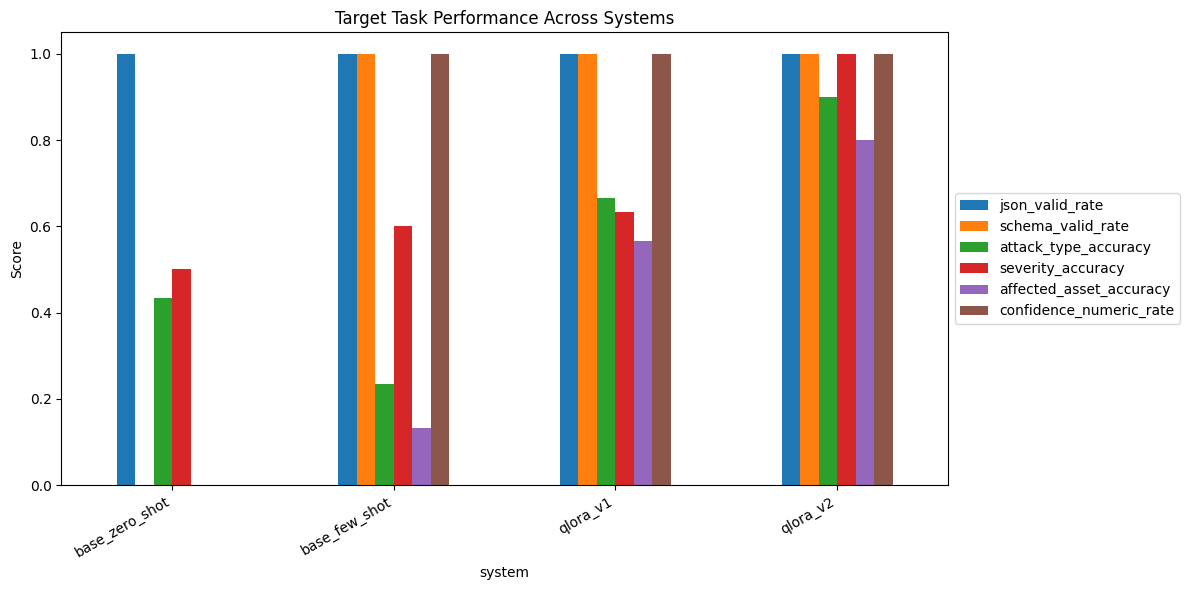

Saved target task comparison plot to: /content/qlora-cyber-threat-json/results/plots/target_task_model_comparison.png


In [41]:
import matplotlib.pyplot as plt

final_comparison_df = pd.read_csv(RESULTS_DIR / "final_model_comparison.csv")

plot_dir = RESULTS_DIR / "plots"
plot_dir.mkdir(exist_ok=True)

metrics_to_plot = [
    "json_valid_rate",
    "schema_valid_rate",
    "attack_type_accuracy",
    "severity_accuracy",
    "affected_asset_accuracy",
    "confidence_numeric_rate"
]

comparison_plot_df = final_comparison_df.set_index("system")[metrics_to_plot]

ax = comparison_plot_df.plot(kind="bar", figsize=(12, 6))

plt.title("Target Task Performance Across Systems")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

target_task_plot_path = plot_dir / "target_task_model_comparison.png"
plt.savefig(target_task_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved target task comparison plot to:", target_task_plot_path)

### Capability regression comparison plot

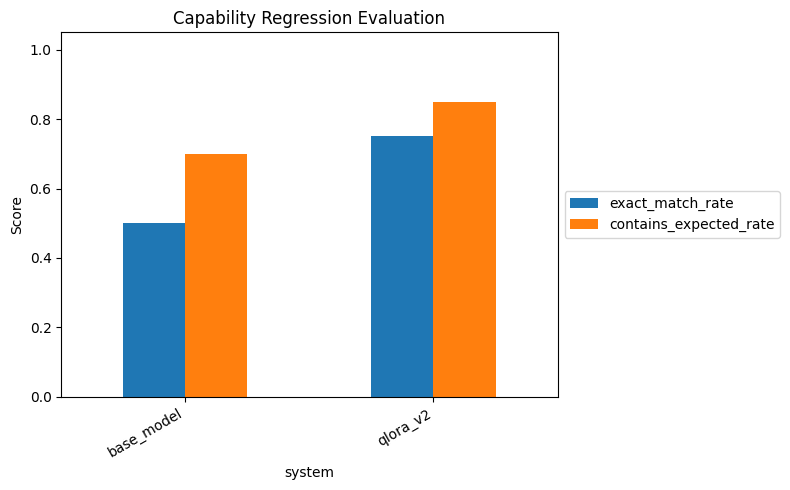

Saved regression comparison plot to: /content/qlora-cyber-threat-json/results/plots/regression_comparison.png


In [42]:
import matplotlib.pyplot as plt

regression_summary_overall_df = pd.read_csv(RESULTS_DIR / "regression_summary_overall.csv")

plot_dir = RESULTS_DIR / "plots"
plot_dir.mkdir(exist_ok=True)

regression_plot_df = regression_summary_overall_df.set_index("system")[
    ["exact_match_rate", "contains_expected_rate"]
]

ax = regression_plot_df.plot(kind="bar", figsize=(8, 5))

plt.title("Capability Regression Evaluation")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

regression_plot_path = plot_dir / "regression_comparison.png"
plt.savefig(regression_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved regression comparison plot to:", regression_plot_path)

### Create clean main-metrics comparison plot

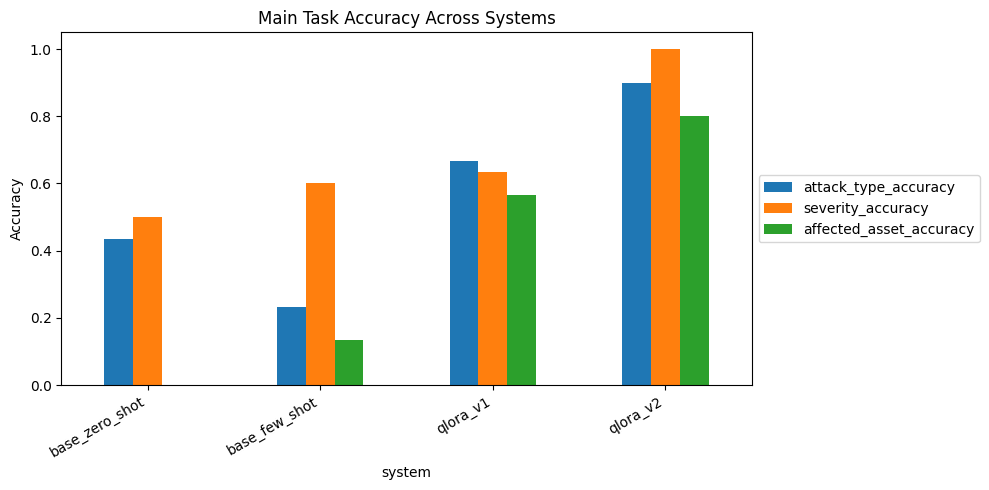

Saved main metrics plot to: /content/qlora-cyber-threat-json/results/plots/main_task_accuracy_comparison.png


In [43]:
main_metrics_df = pd.read_csv(RESULTS_DIR / "final_model_comparison.csv")

plot_dir = RESULTS_DIR / "plots"
plot_dir.mkdir(exist_ok=True)

main_metrics_to_plot = [
    "attack_type_accuracy",
    "severity_accuracy",
    "affected_asset_accuracy"
]

main_plot_df = main_metrics_df.set_index("system")[main_metrics_to_plot]

ax = main_plot_df.plot(kind="bar", figsize=(10, 5))

plt.title("Main Task Accuracy Across Systems")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.legend(loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()

main_metrics_plot_path = plot_dir / "main_task_accuracy_comparison.png"
plt.savefig(main_metrics_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved main metrics plot to:", main_metrics_plot_path)

In [44]:
backup_dir = Path("/content/drive/MyDrive/qlora-cyber-threat-json-backup")

if backup_dir.exists():
    shutil.rmtree(backup_dir)

shutil.copytree(PROJECT_DIR, backup_dir)

print("Backed up updated project folder to:", backup_dir)

print("\nBacked up results files:")
for f in sorted((backup_dir / "results").glob("*")):
    print("-", f.name)

print("\nBacked up plot files:")
for f in sorted((backup_dir / "results" / "plots").glob("*")):
    print("-", f.name)

print("\nBacked up adapter folders:")
for f in sorted((backup_dir / "adapters").glob("*")):
    print("-", f.name)

Backed up updated project folder to: /content/drive/MyDrive/qlora-cyber-threat-json-backup

Backed up results files:
- baseline_comparison.csv
- comparison_zero_fewshot_lora_v1.csv
- few_shot_results.csv
- few_shot_summary.json
- final_model_comparison.csv
- lora_v1_asset_confusion.csv
- lora_v1_attack_confusion.csv
- lora_v1_failures.csv
- lora_v1_results.csv
- lora_v1_severity_confusion.csv
- lora_v1_summary.json
- lora_v2_results.csv
- lora_v2_summary.json
- plots
- regression_all_results.csv
- regression_summary_by_category.csv
- regression_summary_overall.csv
- training_logs_v1.csv
- training_logs_v1.json
- training_logs_v2.csv
- training_logs_v2.json
- v1_failure_analysis_notes.json
- zero_shot_results.csv
- zero_shot_summary.json

Backed up plot files:
- main_task_accuracy_comparison.png
- regression_comparison.png
- target_task_model_comparison.png

Backed up adapter folders:
- lora_v1
- lora_v1_final
- lora_v2
- lora_v2_final


 v1 vs v2 training/eval loss curve

In [45]:
training_logs_v1 = pd.read_csv(RESULTS_DIR / "training_logs_v1.csv")
training_logs_v2 = pd.read_csv(RESULTS_DIR / "training_logs_v2.csv")

display(training_logs_v1.head())
display(training_logs_v2.head())

print("v1 log columns:", list(training_logs_v1.columns))
print("v2 log columns:", list(training_logs_v2.columns))

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.912798,0.908454,0.000197,0.082576,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.263703,0.456123,0.000180,0.165153,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.161496,0.262387,0.000162,0.247729,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.143002,0.227965,0.000144,0.330306,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,0.330306,100,0.137588,71.8294,5.959,5.959,NaN,NaN,NaN,NaN,NaN


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.145476,0.327074,0.000099,0.076511,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.137114,0.231667,0.000091,0.153022,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.133881,0.253999,0.000082,0.229533,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.129655,0.181828,0.000074,0.306044,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,0.306044,100,0.118994,71.755,5.965,5.965,NaN,NaN,NaN,NaN,NaN


v1 log columns: ['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']
v2 log columns: ['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


Plot v1 vs v2 training and validation loss curves

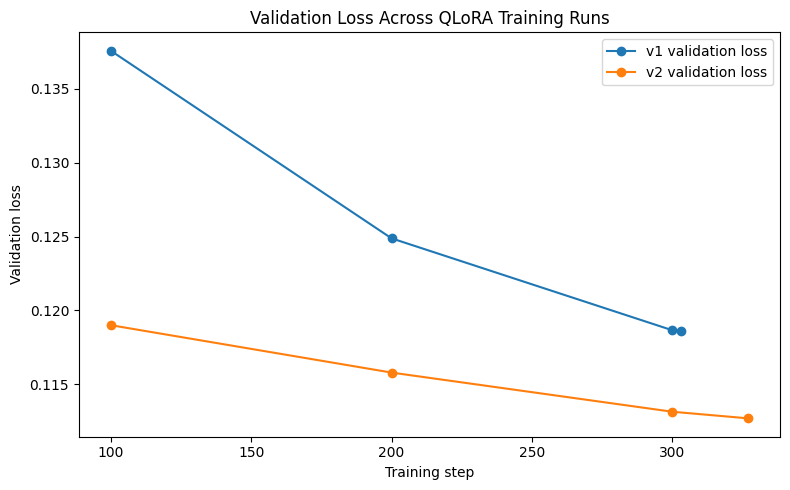

Saved validation loss comparison plot to: /content/qlora-cyber-threat-json/results/plots/validation_loss_comparison.png


In [47]:
training_logs_v1 = pd.read_csv(RESULTS_DIR / "training_logs_v1.csv")
training_logs_v2 = pd.read_csv(RESULTS_DIR / "training_logs_v2.csv")

plot_dir = RESULTS_DIR / "plots"
plot_dir.mkdir(exist_ok=True)

v1_eval_loss = training_logs_v1.dropna(subset=["eval_loss"])
v2_eval_loss = training_logs_v2.dropna(subset=["eval_loss"])

plt.figure(figsize=(8, 5))

plt.plot(v1_eval_loss["step"], v1_eval_loss["eval_loss"], marker="o", label="v1 validation loss")
plt.plot(v2_eval_loss["step"], v2_eval_loss["eval_loss"], marker="o", label="v2 validation loss")

plt.title("Validation Loss Across QLoRA Training Runs")
plt.xlabel("Training step")
plt.ylabel("Validation loss")
plt.legend()
plt.tight_layout()

validation_loss_plot_path = plot_dir / "validation_loss_comparison.png"
plt.savefig(validation_loss_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved validation loss comparison plot to:", validation_loss_plot_path)

Both QLoRA runs showed decreasing validation loss. V2 started from the trained v1 adapter and used targeted augmentation, resulting in a lower final validation loss than v1.

In [48]:
# final experiment summary
final_experiment_summary = {
    "project_title": "QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation",
    "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "fine_tuning_method": "QLoRA / LoRA adapters with 4-bit quantization",
    "task": "Convert cybersecurity logs or incident descriptions into structured threat-analysis JSON.",
    "json_fields": [
        "attack_type",
        "severity",
        "affected_asset",
        "recommended_action",
        "confidence"
    ],
    "dataset": {
        "raw_source": "UNSW-NB15 Kaggle mirror",
        "raw_rows": 2540047,
        "curated_v1_examples": 2850,
        "train_v1_examples": 2422,
        "dev_v1_examples": 428,
        "train_v2_examples": 2614,
        "manual_eval_examples": 30,
        "v2_change": "Targeted oversampled augmentation for v1 failure patterns: worm/backdoor/generic/reconnaissance confusion, critical severity, and affected_asset normalization."
    },
    "target_task_results": final_comparison_df.to_dict(orient="records"),
    "regression_results_overall": regression_summary_overall_df.to_dict(orient="records"),
    "training_loss_summary": {
        "v1_final_validation_loss": float(v1_eval_loss["eval_loss"].iloc[-1]),
        "v2_final_validation_loss": float(v2_eval_loss["eval_loss"].iloc[-1])
    },
    "main_conclusion": "QLoRA v2 substantially improved structured cybersecurity JSON generation over zero-shot, few-shot, and QLoRA v1 baselines while showing no measured regression on the small unrelated benchmark."
}

final_summary_path = RESULTS_DIR / "final_experiment_summary.json"

with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_experiment_summary, f, indent=2)

print("Saved final experiment summary to:", final_summary_path)
print(json.dumps(final_experiment_summary, indent=2))

Saved final experiment summary to: /content/qlora-cyber-threat-json/results/final_experiment_summary.json
{
  "project_title": "QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation",
  "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
  "fine_tuning_method": "QLoRA / LoRA adapters with 4-bit quantization",
  "task": "Convert cybersecurity logs or incident descriptions into structured threat-analysis JSON.",
  "json_fields": [
    "attack_type",
    "severity",
    "affected_asset",
    "recommended_action",
    "confidence"
  ],
  "dataset": {
    "raw_source": "UNSW-NB15 Kaggle mirror",
    "raw_rows": 2540047,
    "curated_v1_examples": 2850,
    "train_v1_examples": 2422,
    "dev_v1_examples": 428,
    "train_v2_examples": 2614,
    "manual_eval_examples": 30,
    "v2_change": "Targeted oversampled augmentation for v1 failure patterns: worm/backdoor/generic/reconnaissance confusion, critical severity, and affected_asset normalization."
  },
  "target_task_results": [
    {

### README

In [50]:
readme_text = """# QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation

## Project Overview

This project fine-tunes a small open-weight instruction model for a cybersecurity structured generation task.

The goal is to convert cybersecurity logs or incident descriptions into structured threat-analysis JSON with the following fields:

- `attack_type`
- `severity`
- `affected_asset`
- `recommended_action`
- `confidence`

The project compares a base model with zero-shot prompting, few-shot prompting, QLoRA v1, and QLoRA v2.

## Base Model

The base model used in this project is:

`Qwen/Qwen2.5-1.5B-Instruct`

## Fine-Tuning Method

The model is fine-tuned using QLoRA/LoRA adapters with 4-bit quantization. This avoids full fine-tuning of the entire model and trains only a small number of adapter parameters.

The v1 LoRA adapter trained approximately 9.23 million trainable parameters out of approximately 1.55 billion total parameters.

## Dataset

The raw dataset source was a Kaggle mirror of the UNSW-NB15 cybersecurity dataset.

Raw dataset size:

- 2,540,047 rows

The raw dataset was not used directly. It was curated through the following steps:

1. Loaded the four raw UNSW-NB15 CSV files and the feature-name file.
2. Assigned official column names to the raw CSV files.
3. Cleaned whitespace and inconsistent attack category labels.
4. Mapped original UNSW-NB15 attack categories into a smaller project taxonomy.
5. Replaced missing attack categories with `benign` for rows where the binary label was 0.
6. Sampled a mostly class-balanced subset for v1.
7. Converted each selected network-flow row into a natural-language cybersecurity event description.
8. Created structured JSON targets with `attack_type`, `severity`, `affected_asset`, `recommended_action`, and `confidence`.
9. Split curated examples into train/dev using stratified sampling by `attack_type`.

## Dataset Sizes

| Split | Examples |
|---|---:|
| Curated v1 total | 2,850 |
| Train v1 | 2,422 |
| Dev v1 | 428 |
| Train v2 | 2,614 |
| Manual held-out eval | 30 |

## Attack Type Taxonomy

The project uses the following attack types:

- `benign`
- `generic_attack`
- `exploit`
- `dos`
- `reconnaissance`
- `fuzzing`
- `analysis`
- `backdoor`
- `shellcode`
- `worm`
- `unknown`

## Evaluation Setup

The same manually created held-out evaluation set was used for all target-task systems.

Systems compared:

1. Base model zero-shot prompting
2. Base model few-shot prompting
3. QLoRA v1
4. QLoRA v2

Metrics:

- JSON validity rate
- Schema validity rate
- Attack type accuracy
- Severity accuracy
- Affected asset accuracy
- Numeric confidence rate

## Target Task Results

| System | JSON Valid | Schema Valid | Attack Accuracy | Severity Accuracy | Asset Accuracy | Numeric Confidence |
|---|---:|---:|---:|---:|---:|---:|
| Base zero-shot | 1.00 | 0.00 | 0.433 | 0.500 | 0.000 | 0.00 |
| Base few-shot | 1.00 | 1.00 | 0.233 | 0.600 | 0.133 | 1.00 |
| QLoRA v1 | 1.00 | 1.00 | 0.667 | 0.633 | 0.567 | 1.00 |
| QLoRA v2 | 1.00 | 1.00 | 0.900 | 1.000 | 0.800 | 1.00 |

## V1 to V2 Iteration

After evaluating QLoRA v1, the main observed weaknesses were:

- Worm examples were often confused with DoS.
- Backdoor examples were sometimes predicted as benign.
- Critical severity was sometimes downgraded.
- Affected asset labels were sometimes semantically reasonable but not normalized to the project taxonomy.
- `network_service` and `network_host` were frequently confused.

For QLoRA v2, the project used targeted oversampled augmentation focused on these v1 failure patterns. The base model and general training approach were kept the same so that the v2 change was focused and interpretable.

V2 improved:

- Attack accuracy from 66.7% to 90.0%
- Severity accuracy from 63.3% to 100.0%
- Affected asset accuracy from 56.7% to 80.0%

## Capability Regression Evaluation

To check whether fine-tuning harmed unrelated capabilities, the project evaluated the base model and QLoRA v2 on a small manually created regression benchmark with two categories:

1. Reasoning/arithmetic
2. Instruction following

| System | Examples | Exact Match | Contains Expected |
|---|---:|---:|---:|
| Base model | 20 | 0.50 | 0.70 |
| QLoRA v2 | 20 | 0.75 | 0.85 |

No measurable regression was observed on this small benchmark. QLoRA v2 performed slightly better, possibly because the fine-tuning task encouraged concise structured outputs.

## Training Loss Summary

| Run | Final Validation Loss |
|---|---:|
| QLoRA v1 | 0.118607 |
| QLoRA v2 | 0.112683 |

Both runs showed decreasing validation loss. QLoRA v2 ended with a lower validation loss than QLoRA v1.

## Important Files

### Data

- `data/processed/train_v1.jsonl`
- `data/processed/dev_v1.jsonl`
- `data/processed/train_v2.jsonl`
- `data/processed/manual_eval.jsonl`
- `data/processed/train_v1_sft.jsonl`
- `data/processed/train_v2_sft.jsonl`
- `data/processed/dataset_summary_v1.json`

### Results

- `results/final_model_comparison.csv`
- `results/lora_v1_results.csv`
- `results/lora_v2_results.csv`
- `results/regression_all_results.csv`
- `results/regression_summary_overall.csv`
- `results/v1_failure_analysis_notes.json`
- `results/final_experiment_summary.json`

### Plots

- `results/plots/main_task_accuracy_comparison.png`
- `results/plots/regression_comparison.png`
- `results/plots/validation_loss_comparison.png`

### Adapters

- `adapters/lora_v1_final/`
- `adapters/lora_v2_final/`

## Main Conclusion

QLoRA v2 substantially improved structured cybersecurity JSON generation over zero-shot prompting, few-shot prompting, and QLoRA v1. The strongest improvement was on the project-specific structured fields, especially `attack_type`, `severity`, and `affected_asset`. The small capability regression benchmark did not show measurable degradation after fine-tuning.
"""

readme_path = PROJECT_DIR / "README.md"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_text)

print("Saved README to:", readme_path)

Saved README to: /content/qlora-cyber-threat-json/README.md


final report/writeup draft

In [51]:
report_text = """# QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation

## 1. Introduction

This project investigates whether LoRA/QLoRA fine-tuning can improve a small open-weight instruction model on a narrow cybersecurity structured generation task. The goal is to build a small AI security assistant that converts cybersecurity logs or incident descriptions into structured threat-analysis JSON.

The model receives an input such as a network-flow description or a natural-language incident report and must output valid JSON with the following fields:

- `attack_type`
- `severity`
- `affected_asset`
- `recommended_action`
- `confidence`

This task was chosen because it is narrow, measurable, realistic for a small model, and relevant to AI-assisted cybersecurity workflows. It is also suitable for evaluating whether LoRA fine-tuning provides a measurable benefit over prompting-only baselines.

The base model used was `Qwen/Qwen2.5-1.5B-Instruct`. The model was fine-tuned using QLoRA/LoRA adapters with 4-bit quantization rather than full fine-tuning. This kept the project feasible on a Colab T4 GPU while still allowing task-specific adaptation.

## 2. Dataset Construction

The raw source dataset was a Kaggle mirror of the UNSW-NB15 cybersecurity dataset. The raw dataset contained 2,540,047 rows of network-flow records. The raw dataset was not used directly. Instead, I curated it into a structured instruction-tuning dataset.

The dataset construction process involved the following steps:

1. Loading the four raw UNSW-NB15 CSV files and the official feature-name file.
2. Assigning official column names to the raw CSV files.
3. Cleaning whitespace and inconsistent attack category labels.
4. Mapping original UNSW-NB15 attack categories into a smaller project taxonomy.
5. Replacing missing attack categories with `benign` for rows where the binary label was 0.
6. Sampling a mostly class-balanced subset for v1.
7. Converting each selected network-flow row into a natural-language cybersecurity event description.
8. Creating structured JSON targets with `attack_type`, `severity`, `affected_asset`, `recommended_action`, and `confidence`.
9. Splitting curated examples into train/dev sets using stratified sampling by `attack_type`.

The final v1 curated dataset contained 2,850 examples. These were split into 2,422 training examples and 428 development examples. A separate manually created held-out evaluation set of 30 examples was used for final target-task evaluation.

The attack taxonomy used in this project was:

- `benign`
- `generic_attack`
- `exploit`
- `dos`
- `reconnaissance`
- `fuzzing`
- `analysis`
- `backdoor`
- `shellcode`
- `worm`
- `unknown`

The output severity values were:

- `low`
- `medium`
- `high`
- `critical`

## 3. Model and Fine-Tuning Method

The base model was `Qwen/Qwen2.5-1.5B-Instruct`. I used QLoRA/LoRA adapter fine-tuning with 4-bit quantization. This allowed the model to be trained efficiently on limited GPU resources.

For v1, the LoRA configuration used approximately 9.23 million trainable parameters out of approximately 1.55 billion total parameters, meaning only about 0.59% of the model parameters were trainable. This is consistent with the goal of parameter-efficient fine-tuning.

The v1 training setup used:

- 1 training epoch
- batch size 1
- gradient accumulation steps 8
- learning rate 2e-4
- 4-bit quantized base model
- LoRA target modules including attention and MLP projection layers

## 4. Baselines

Before LoRA fine-tuning, I evaluated two prompting baselines using the same 30-example manual evaluation set:

1. Base model zero-shot prompting
2. Base model few-shot prompting

The zero-shot baseline gave the model the task instructions but no examples. The few-shot baseline included several input/output demonstrations before the test input.

The goal of these baselines was to determine whether LoRA fine-tuning actually improved performance over prompting alone.

## 5. Evaluation Metrics

For the target cybersecurity JSON task, I evaluated:

- JSON validity rate
- Schema validity rate
- Attack type accuracy
- Severity accuracy
- Affected asset accuracy
- Numeric confidence rate

A prediction was counted as schema-valid only if it contained all required keys, used an allowed `attack_type`, used an allowed `severity`, had a string `recommended_action`, and had a numeric confidence value between 0 and 1.

## 6. Target Task Results

The final results on the 30-example manual evaluation set were:

| System | JSON Valid | Schema Valid | Attack Accuracy | Severity Accuracy | Asset Accuracy | Numeric Confidence |
|---|---:|---:|---:|---:|---:|---:|
| Base zero-shot | 1.00 | 0.00 | 0.433 | 0.500 | 0.000 | 0.00 |
| Base few-shot | 1.00 | 1.00 | 0.233 | 0.600 | 0.133 | 1.00 |
| QLoRA v1 | 1.00 | 1.00 | 0.667 | 0.633 | 0.567 | 1.00 |
| QLoRA v2 | 1.00 | 1.00 | 0.900 | 1.000 | 0.800 | 1.00 |

The zero-shot model usually produced JSON-shaped outputs, but it did not follow the project schema reliably. For example, it often produced non-normalized affected assets such as `public website` instead of `web_service`, and it sometimes used non-numeric confidence values such as `medium`.

The few-shot baseline improved schema validity and numeric confidence, but it did not improve attack classification. In fact, its attack accuracy was lower than the zero-shot baseline. This suggests that prompting helped the output format but did not reliably teach the model the project-specific cybersecurity taxonomy.

QLoRA v1 substantially improved task performance over both prompting baselines. Attack accuracy increased to 66.7%, and affected asset accuracy increased to 56.7%.

QLoRA v2 further improved the results. It achieved 90.0% attack accuracy, 100.0% severity accuracy, and 80.0% affected asset accuracy. This shows that LoRA fine-tuning provided a clear benefit over both zero-shot and few-shot prompting.

## 7. V1 Failure Analysis and V2 Iteration

After evaluating QLoRA v1, I analyzed its failure cases. The main weaknesses were:

- Worm examples were consistently confused with DoS.
- Backdoor examples were sometimes predicted as benign.
- Critical severity was sometimes downgraded.
- Affected asset labels were sometimes semantically reasonable but not normalized to the project taxonomy.
- `network_service` and `network_host` were frequently confused.

Based on this analysis, I created a v2 dataset by adding targeted oversampled augmentation examples. These examples focused on the specific v1 failure patterns: worm, backdoor, generic attack, reconnaissance, critical severity, and affected asset normalization.

The v2 training set contained 2,614 examples. This included the original v1 training examples plus targeted oversampled examples. The v2 model continued training from the v1 LoRA adapter with a lower learning rate of 1e-4.

This focused change improved the target-task results:

- Attack accuracy improved from 66.7% to 90.0%.
- Severity accuracy improved from 63.3% to 100.0%.
- Affected asset accuracy improved from 56.7% to 80.0%.

This supports the hypothesis that targeted dataset improvement based on v1 failure analysis can improve a LoRA fine-tuned model without changing the entire training setup.

## 8. Training Dynamics

Both QLoRA runs showed decreasing validation loss. QLoRA v1 ended with a final validation loss of approximately 0.118607. QLoRA v2 ended with a lower final validation loss of approximately 0.112683.

| Run | Final Validation Loss |
|---|---:|
| QLoRA v1 | 0.118607 |
| QLoRA v2 | 0.112683 |

The validation loss trend supports the manual evaluation results: v2 improved both validation loss and field-level task accuracy.

## 9. Capability Regression Evaluation

To check whether fine-tuning harmed unrelated capabilities, I created a small regression benchmark with 20 examples across two unrelated categories:

1. Reasoning/arithmetic
2. Instruction following

The base model and QLoRA v2 were evaluated on the same examples.

| System | Examples | Exact Match | Contains Expected |
|---|---:|---:|---:|
| Base model | 20 | 0.50 | 0.70 |
| QLoRA v2 | 20 | 0.75 | 0.85 |

On this small regression benchmark, QLoRA v2 did not show measurable capability degradation. It performed slightly better than the base model on exact match and contains-expected metrics. One possible reason is that the cybersecurity fine-tuning task trained the model to produce concise, structured outputs, which may have helped some instruction-following examples.

However, this regression benchmark was small, so the result should not be interpreted as proving broad general capability improvement. It only shows that no regression was observed on this limited test set.

## 10. Limitations

This project has several limitations.

First, the manual held-out evaluation set contained only 30 examples. This was enough to compare systems consistently, but a larger evaluation set would provide more reliable estimates.

Second, the dataset construction involved rule-based mapping from network-flow rows to natural-language descriptions and JSON fields. This made the task measurable and feasible, but the generated descriptions may not fully represent the variety of real-world security analyst reports.

Third, the capability regression benchmark was small and manually constructed. It checked two unrelated capability categories, but it was not a comprehensive general benchmark.

Fourth, the v2 targeted augmentation was intentionally focused on v1 weaknesses. This helped improve the held-out task performance, but future work should evaluate on a larger and more diverse test set to make sure the improvement generalizes.

## 11. Conclusion

This project showed that QLoRA fine-tuning can substantially improve a small instruction model on a narrow cybersecurity structured generation task.

The base model could often produce JSON-like text, but it did not reliably follow the required schema or project-specific taxonomy. Few-shot prompting improved formatting but did not solve the taxonomy problem. QLoRA v1 improved task accuracy over both prompted baselines. After analyzing v1 failures and applying targeted v2 augmentation, QLoRA v2 achieved the best results across the main task metrics.

The strongest final result was QLoRA v2, which achieved:

- 90.0% attack type accuracy
- 100.0% severity accuracy
- 80.0% affected asset accuracy
- 100.0% schema validity
- 100.0% numeric confidence rate

The small capability regression evaluation did not show degradation after fine-tuning. Overall, the results support the conclusion that LoRA/QLoRA provided a clear benefit over prompting-only baselines for this structured cybersecurity JSON generation task.
"""

report_path = PROJECT_DIR / "report_writeup_draft.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report_text)

print("Saved report draft to:", report_path)

Saved report draft to: /content/qlora-cyber-threat-json/report_writeup_draft.md


In [54]:
print("Top-level project files:")
for f in sorted(PROJECT_DIR.glob("*")):
    print("-", f.name)

print("\nProcessed data files:")
for f in sorted(PROCESSED_DIR.glob("*")):
    print("-", f.name)

print("\nResults files:")
for f in sorted(RESULTS_DIR.glob("*")):
    print("-", f.name)

print("\nPlot files:")
for f in sorted((RESULTS_DIR / "plots").glob("*")):
    print("-", f.name)

print("\nAdapter folders:")
for f in sorted(ADAPTERS_DIR.glob("*")):
    print("-", f.name)

Top-level project files:
- README.md
- adapters
- data
- report_writeup_draft.md
- results

Processed data files:
- dataset_summary_v1.json
- dev_v1.jsonl
- dev_v1_sft.jsonl
- manual_eval.jsonl
- manual_eval_sft.jsonl
- train_v1.jsonl
- train_v1_sft.jsonl
- train_v2.jsonl
- train_v2_sft.jsonl

Results files:
- baseline_comparison.csv
- comparison_zero_fewshot_lora_v1.csv
- few_shot_results.csv
- few_shot_summary.json
- final_experiment_summary.json
- final_model_comparison.csv
- lora_v1_asset_confusion.csv
- lora_v1_attack_confusion.csv
- lora_v1_failures.csv
- lora_v1_results.csv
- lora_v1_severity_confusion.csv
- lora_v1_summary.json
- lora_v2_results.csv
- lora_v2_summary.json
- plots
- regression_all_results.csv
- regression_summary_by_category.csv
- regression_summary_overall.csv
- training_logs_v1.csv
- training_logs_v1.json
- training_logs_v2.csv
- training_logs_v2.json
- v1_failure_analysis_notes.json
- zero_shot_results.csv
- zero_shot_summary.json

Plot files:
- main_task_acc

In [55]:
readme_path = PROJECT_DIR / "README.md"
report_path = PROJECT_DIR / "report_writeup_draft.md"

print("README exists:", readme_path.exists())
print("Report exists:", report_path.exists())

print("\nREADME preview:")
print(readme_path.read_text(encoding="utf-8")[:1500])

print("\n" + "="*100 + "\n")

print("Report preview:")
print(report_path.read_text(encoding="utf-8")[:2500])

README exists: True
Report exists: True

README preview:
# QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation

## Project Overview

This project fine-tunes a small open-weight instruction model for a cybersecurity structured generation task.

The goal is to convert cybersecurity logs or incident descriptions into structured threat-analysis JSON with the following fields:

- `attack_type`
- `severity`
- `affected_asset`
- `recommended_action`
- `confidence`

The project compares a base model with zero-shot prompting, few-shot prompting, QLoRA v1, and QLoRA v2.

## Base Model

The base model used in this project is:

`Qwen/Qwen2.5-1.5B-Instruct`

## Fine-Tuning Method

The model is fine-tuned using QLoRA/LoRA adapters with 4-bit quantization. This avoids full fine-tuning of the entire model and trains only a small number of adapter parameters.

The v1 LoRA adapter trained approximately 9.23 million trainable parameters out of approximately 1.55 billion total parameters.


Final blind evaluation

In [56]:
final_blind_eval_examples = [
    {
        "input": "A customer-facing web portal became unavailable after receiving a very large number of requests from many unrelated source addresses.",
        "output": {
            "attack_type": "dos",
            "severity": "critical",
            "affected_asset": "web_service",
            "recommended_action": "Enable rate limiting or DDoS protection, block abusive sources, and monitor service availability.",
            "confidence": 0.90
        }
    },
    {
        "input": "An internal workstation attempted to connect to many neighboring machines in a repeated automated pattern, suggesting self-propagating malware behavior.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "A server kept an unauthorized remote access channel open after the original intrusion, allowing the attacker to return later.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "A public API endpoint received crafted requests that attempted to trigger a known software vulnerability.",
        "output": {
            "attack_type": "exploit",
            "severity": "high",
            "affected_asset": "web_service",
            "recommended_action": "Inspect the web service for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
            "confidence": 0.88
        }
    },
    {
        "input": "A host sent connection attempts to many different ports on the same destination to identify exposed services.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Review scanning activity, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "Malformed packets were sent repeatedly to a network daemon, apparently to test how the service handles unexpected input.",
        "output": {
            "attack_type": "fuzzing",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Review service crash logs, validate input handling, and apply patches or filtering rules if instability is observed.",
            "confidence": 0.86
        }
    },
    {
        "input": "A security device reported malicious traffic against a service, but the indicators did not clearly match scanning, exploitation, fuzzing, worm behavior, or denial of service.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "A suspicious payload containing low-level executable instructions was detected while being delivered to a listening service.",
        "output": {
            "attack_type": "shellcode",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Block the payload source, inspect the affected service for compromise, and patch vulnerabilities that allow code execution.",
            "confidence": 0.89
        }
    },
    {
        "input": "An attacker appeared to collect information about host configuration and possible weaknesses before launching a direct attack.",
        "output": {
            "attack_type": "analysis",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Review information-gathering activity, limit exposed diagnostic details, and monitor for follow-up attacks.",
            "confidence": 0.84
        }
    },
    {
        "input": "An internal workstation performed a routine DNS query with normal traffic volume and no suspicious indicators.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "dns_service",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the dns_service.",
            "confidence": 0.84
        }
    },
    {
        "input": "The company mail server received normal SMTP traffic from a trusted internal relay with expected volume.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "mail_server",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the mail_server.",
            "confidence": 0.84
        }
    },
    {
        "input": "A database-backed web application received suspicious input containing SQL syntax intended to manipulate a backend query.",
        "output": {
            "attack_type": "exploit",
            "severity": "high",
            "affected_asset": "web_service",
            "recommended_action": "Inspect the web service for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
            "confidence": 0.88
        }
    },
    {
        "input": "Many external hosts sent high-volume traffic to the same public service until legitimate users experienced timeouts.",
        "output": {
            "attack_type": "dos",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Enable rate limiting or DDoS protection for the network_service, block abusive sources, and monitor service availability.",
            "confidence": 0.90
        }
    },
    {
        "input": "A compromised endpoint continued to contact a command server after reboot, suggesting unauthorized persistence.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "A host generated repeated automated connection attempts toward multiple internal systems, consistent with malware spreading behavior.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "A source address probed several services across the environment to discover which systems were reachable.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Review scanning activity, restrict exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "A network service received unusual random-looking inputs designed to trigger crashes or unexpected behavior.",
        "output": {
            "attack_type": "fuzzing",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Review service crash logs, validate input handling, and apply patches or filtering rules if instability is observed.",
            "confidence": 0.86
        }
    },
    {
        "input": "The IDS marked a flow as hostile, but the event lacked enough detail to assign it to a specific attack family.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "Executable payload fragments were observed in traffic targeting a server process.",
        "output": {
            "attack_type": "shellcode",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Block the payload source, inspect the affected service for compromise, and patch vulnerabilities that allow code execution.",
            "confidence": 0.89
        }
    },
    {
        "input": "A suspicious actor appeared to examine available services and gather technical details about a target host.",
        "output": {
            "attack_type": "analysis",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Review information-gathering activity, limit exposed diagnostic details, and monitor for follow-up attacks.",
            "confidence": 0.84
        }
    },
    {
        "input": "A normal web request was served successfully by the public website with no abnormal traffic pattern.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "web_service",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the web_service.",
            "confidence": 0.84
        }
    },
    {
        "input": "A normal SSH login from a known administrator account completed successfully from an expected internal address.",
        "output": {
            "attack_type": "benign",
            "severity": "low",
            "affected_asset": "network_host",
            "recommended_action": "No immediate security action is required. Continue routine monitoring of the network_host.",
            "confidence": 0.84
        }
    },
    {
        "input": "A vulnerable application endpoint was targeted with crafted input designed to execute unintended behavior.",
        "output": {
            "attack_type": "exploit",
            "severity": "high",
            "affected_asset": "web_service",
            "recommended_action": "Inspect the web service for signs of exploitation, patch vulnerable software, review access logs, and block suspicious source traffic.",
            "confidence": 0.88
        }
    },
    {
        "input": "A public service slowed down after receiving repeated connection floods from external sources.",
        "output": {
            "attack_type": "dos",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Enable rate limiting or DDoS protection for the network_service, block abusive sources, and monitor service availability.",
            "confidence": 0.90
        }
    },
    {
        "input": "A suspicious service remained available for remote attacker access even after the original intrusion activity ended.",
        "output": {
            "attack_type": "backdoor",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Isolate the affected host, search for unauthorized persistence mechanisms, rotate credentials, and perform forensic analysis.",
            "confidence": 0.90
        }
    },
    {
        "input": "Automated traffic from one internal machine attempted to spread to several other hosts without user action.",
        "output": {
            "attack_type": "worm",
            "severity": "critical",
            "affected_asset": "network_host",
            "recommended_action": "Immediately isolate the affected host, scan nearby hosts, block propagation paths, and begin incident response procedures.",
            "confidence": 0.90
        }
    },
    {
        "input": "A scanner checked a range of ports to identify exposed services on a target system.",
        "output": {
            "attack_type": "reconnaissance",
            "severity": "medium",
            "affected_asset": "network_host",
            "recommended_action": "Review scanning activity, restrict unnecessary exposed services, and monitor for follow-up intrusion attempts.",
            "confidence": 0.86
        }
    },
    {
        "input": "An application service received malformed protocol messages intended to test input validation behavior.",
        "output": {
            "attack_type": "fuzzing",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Review service crash logs, validate input handling, and apply patches or filtering rules if instability is observed.",
            "confidence": 0.86
        }
    },
    {
        "input": "Security monitoring detected malicious behavior against a service, but the available log did not specify the exact method.",
        "output": {
            "attack_type": "generic_attack",
            "severity": "medium",
            "affected_asset": "network_service",
            "recommended_action": "Investigate the suspicious traffic, review logs for the affected service, and apply network blocking or filtering if malicious behavior is confirmed.",
            "confidence": 0.88
        }
    },
    {
        "input": "The traffic contained code-like payload bytes associated with an attempt to execute instructions on the target.",
        "output": {
            "attack_type": "shellcode",
            "severity": "critical",
            "affected_asset": "network_service",
            "recommended_action": "Block the payload source, inspect the affected service for compromise, and patch vulnerabilities that allow code execution.",
            "confidence": 0.89
        }
    }
]

final_blind_eval_path = PROCESSED_DIR / "final_blind_eval.jsonl"

save_jsonl(final_blind_eval_examples, final_blind_eval_path)

print("Final blind eval examples:", len(final_blind_eval_examples))
print("Saved final blind eval to:", final_blind_eval_path)

print("\nAttack type distribution:")
print(pd.Series([ex["output"]["attack_type"] for ex in final_blind_eval_examples]).value_counts())

print("\nAffected asset distribution:")
print(pd.Series([ex["output"]["affected_asset"] for ex in final_blind_eval_examples]).value_counts())

Final blind eval examples: 30
Saved final blind eval to: /content/qlora-cyber-threat-json/data/processed/final_blind_eval.jsonl

Attack type distribution:
benign            4
dos               3
worm              3
backdoor          3
reconnaissance    3
exploit           3
fuzzing           3
generic_attack    3
shellcode         3
analysis          2
Name: count, dtype: int64

Affected asset distribution:
network_service    12
network_host       11
web_service         5
dns_service         1
mail_server         1
Name: count, dtype: int64


blind eval for zero-shot, few-shot, and qlora_v2

In [59]:
CYBER_SYSTEM_PROMPT = """<|system|>
You are a cybersecurity threat analysis assistant.
Given a cybersecurity log or incident description, output ONLY valid JSON with the following keys:
attack_type, severity, affected_asset, recommended_action, confidence.

Allowed attack_type values:
benign, generic_attack, exploit, dos, reconnaissance, fuzzing, analysis, backdoor, shellcode, worm, unknown.

Allowed severity values:
low, medium, high, critical.

Do not include markdown.
Do not include explanations outside JSON.
"""


def build_blind_zero_shot_prompt(input_text):
    prompt = f"""{CYBER_SYSTEM_PROMPT}

<|user|>
Analyze this cybersecurity event:

{input_text}
<|assistant|>
"""
    return prompt


few_shot_demo_indices = [0, 300, 600, 900, 1200]
few_shot_demos = [train_v1_examples[i] for i in few_shot_demo_indices]


def build_blind_few_shot_prompt(input_text):
    examples_text = ""

    for demo in few_shot_demos:
        examples_text += "Example event:\n"
        examples_text += demo["input"] + "\n"
        examples_text += "Example JSON output:\n"
        examples_text += json.dumps(demo["output"], ensure_ascii=False) + "\n\n"

    prompt = f"""{CYBER_SYSTEM_PROMPT}

<|user|>
Here are examples of the task:

{examples_text}
Now analyze this cybersecurity event:

{input_text}
<|assistant|>
"""
    return prompt


def generate_blind_response(model, prompt, max_new_tokens=180, disable_adapter=False):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        if disable_adapter:
            with model.disable_adapter():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    temperature=None,
                    top_p=None,
                    pad_token_id=tokenizer.eos_token_id
                )
        else:
            outputs = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=None,
                top_p=None,
                pad_token_id=tokenizer.eos_token_id
            )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=False)
    generated_text = full_text[len(prompt):].strip()

    return generated_text


def run_blind_eval(eval_examples, system_name, model, prompt_builder, disable_adapter=False):
    rows = []

    for i, ex in enumerate(eval_examples):
        print(f"Running {system_name} example {i+1}/{len(eval_examples)}...")

        prompt = prompt_builder(ex["input"])
        pred_text = generate_blind_response(
            model=model,
            prompt=prompt,
            max_new_tokens=180,
            disable_adapter=disable_adapter
        )

        score = score_prediction(pred_text, ex["output"])

        rows.append({
            "system": system_name,
            "index": i,
            "input": ex["input"],
            "expected_output": json.dumps(ex["output"], ensure_ascii=False),
            "prediction_text": pred_text,
            **score
        })

    return pd.DataFrame(rows)


blind_zero_shot_df = run_blind_eval(
    eval_examples=final_blind_eval_examples,
    system_name="blind_base_zero_shot",
    model=lora_v2_model,
    prompt_builder=build_blind_zero_shot_prompt,
    disable_adapter=True
)

blind_few_shot_df = run_blind_eval(
    eval_examples=final_blind_eval_examples,
    system_name="blind_base_few_shot",
    model=lora_v2_model,
    prompt_builder=build_blind_few_shot_prompt,
    disable_adapter=True
)

blind_lora_v2_df = run_blind_eval(
    eval_examples=final_blind_eval_examples,
    system_name="blind_qlora_v2",
    model=lora_v2_model,
    prompt_builder=build_blind_zero_shot_prompt,
    disable_adapter=False
)

print("Completed clean blind eval for zero-shot, few-shot, and QLoRA v2.")

Running blind_base_zero_shot example 1/30...
Running blind_base_zero_shot example 2/30...
Running blind_base_zero_shot example 3/30...
Running blind_base_zero_shot example 4/30...
Running blind_base_zero_shot example 5/30...
Running blind_base_zero_shot example 6/30...
Running blind_base_zero_shot example 7/30...
Running blind_base_zero_shot example 8/30...
Running blind_base_zero_shot example 9/30...
Running blind_base_zero_shot example 10/30...
Running blind_base_zero_shot example 11/30...
Running blind_base_zero_shot example 12/30...
Running blind_base_zero_shot example 13/30...
Running blind_base_zero_shot example 14/30...
Running blind_base_zero_shot example 15/30...
Running blind_base_zero_shot example 16/30...
Running blind_base_zero_shot example 17/30...
Running blind_base_zero_shot example 18/30...
Running blind_base_zero_shot example 19/30...
Running blind_base_zero_shot example 20/30...
Running blind_base_zero_shot example 21/30...
Running blind_base_zero_shot example 22/30.

blind eval for qlora_v1

In [60]:
lora_v1_path = ADAPTERS_DIR / "lora_v1_final"

print("Loading QLoRA v1 adapter from:", lora_v1_path)

base_model_for_v1_blind = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

lora_v1_blind_model = PeftModel.from_pretrained(
    base_model_for_v1_blind,
    lora_v1_path
)

lora_v1_blind_model.eval()

blind_lora_v1_df = run_blind_eval(
    eval_examples=final_blind_eval_examples,
    system_name="blind_qlora_v1",
    model=lora_v1_blind_model,
    prompt_builder=build_blind_zero_shot_prompt,
    disable_adapter=False
)

print("Completed clean blind eval for QLoRA v1.")

Loading QLoRA v1 adapter from: /content/qlora-cyber-threat-json/adapters/lora_v1_final


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Running blind_qlora_v1 example 1/30...
Running blind_qlora_v1 example 2/30...
Running blind_qlora_v1 example 3/30...
Running blind_qlora_v1 example 4/30...
Running blind_qlora_v1 example 5/30...
Running blind_qlora_v1 example 6/30...
Running blind_qlora_v1 example 7/30...
Running blind_qlora_v1 example 8/30...
Running blind_qlora_v1 example 9/30...
Running blind_qlora_v1 example 10/30...
Running blind_qlora_v1 example 11/30...
Running blind_qlora_v1 example 12/30...
Running blind_qlora_v1 example 13/30...
Running blind_qlora_v1 example 14/30...
Running blind_qlora_v1 example 15/30...
Running blind_qlora_v1 example 16/30...
Running blind_qlora_v1 example 17/30...
Running blind_qlora_v1 example 18/30...
Running blind_qlora_v1 example 19/30...
Running blind_qlora_v1 example 20/30...
Running blind_qlora_v1 example 21/30...
Running blind_qlora_v1 example 22/30...
Running blind_qlora_v1 example 23/30...
Running blind_qlora_v1 example 24/30...
Running blind_qlora_v1 example 25/30...
Running b

final blind evaluation results

In [61]:
blind_all_results_df = pd.concat(
    [
        blind_zero_shot_df,
        blind_few_shot_df,
        blind_lora_v1_df,
        blind_lora_v2_df
    ],
    ignore_index=True
)

blind_all_results_path = RESULTS_DIR / "final_blind_all_results.csv"
blind_all_results_df.to_csv(blind_all_results_path, index=False)

blind_summary_rows = []

for system_name, group_df in blind_all_results_df.groupby("system"):
    blind_summary_rows.append({
        "system": system_name,
        "num_examples": len(group_df),
        "json_valid_rate": group_df["json_valid"].mean(),
        "schema_valid_rate": group_df["schema_valid"].mean(),
        "attack_type_accuracy": group_df["attack_type_correct"].mean(),
        "severity_accuracy": group_df["severity_correct"].mean(),
        "affected_asset_accuracy": group_df["affected_asset_correct"].mean(),
        "confidence_numeric_rate": group_df["confidence_numeric"].mean()
    })

blind_comparison_df = pd.DataFrame(blind_summary_rows)

system_order = [
    "blind_base_zero_shot",
    "blind_base_few_shot",
    "blind_qlora_v1",
    "blind_qlora_v2"
]

blind_comparison_df["system"] = pd.Categorical(
    blind_comparison_df["system"],
    categories=system_order,
    ordered=True
)

blind_comparison_df = blind_comparison_df.sort_values("system").reset_index(drop=True)

blind_comparison_path = RESULTS_DIR / "final_blind_model_comparison.csv"
blind_comparison_df.to_csv(blind_comparison_path, index=False)

blind_summary_json_path = RESULTS_DIR / "final_blind_model_comparison.json"

with open(blind_summary_json_path, "w", encoding="utf-8") as f:
    json.dump(blind_comparison_df.to_dict(orient="records"), f, indent=2)

print("Saved all blind eval results to:", blind_all_results_path)
print("Saved blind comparison CSV to:", blind_comparison_path)
print("Saved blind comparison JSON to:", blind_summary_json_path)

print("\nFinal blind comparison:")
display(blind_comparison_df)

Saved all blind eval results to: /content/qlora-cyber-threat-json/results/final_blind_all_results.csv
Saved blind comparison CSV to: /content/qlora-cyber-threat-json/results/final_blind_model_comparison.csv
Saved blind comparison JSON to: /content/qlora-cyber-threat-json/results/final_blind_model_comparison.json

Final blind comparison:


,system,num_examples,json_valid_rate,schema_valid_rate,attack_type_accuracy,severity_accuracy,affected_asset_accuracy,confidence_numeric_rate
0,blind_base_zero_shot,30,1.0,0.0,0.333333,0.466667,0.000000,0.0
1,blind_base_few_shot,30,1.0,1.0,0.300000,0.633333,0.033333,1.0
2,blind_qlora_v1,30,1.0,1.0,0.500000,0.566667,0.500000,1.0
3,blind_qlora_v2,30,1.0,1.0,0.766667,1.000000,0.733333,1.0


final blind comparison plot

/tmp/ipykernel_14713/2215175135.py:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  plot_df["system_label"] = plot_df["system"].replace({


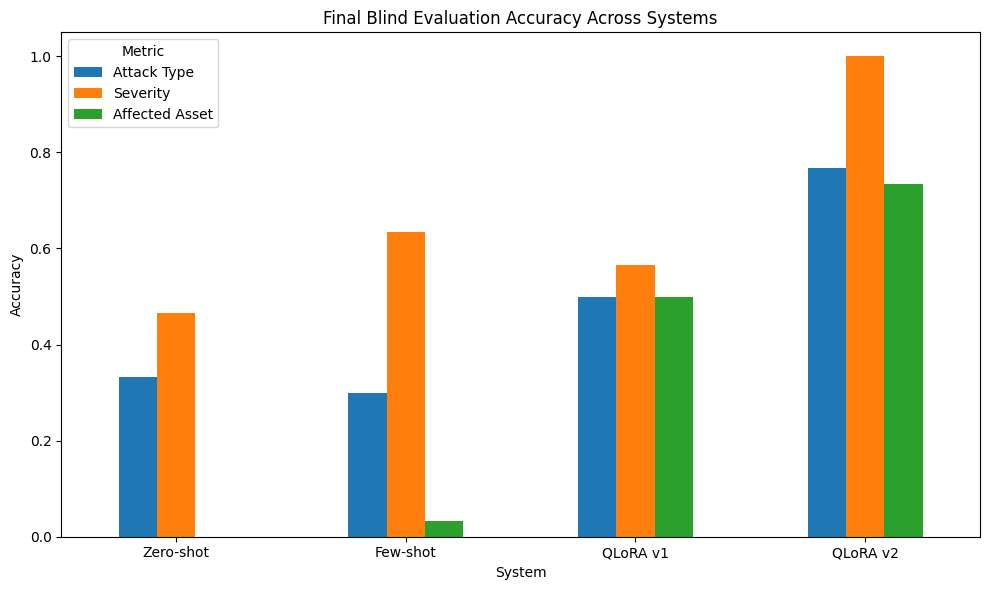

Saved final blind comparison plot to: /content/qlora-cyber-threat-json/results/plots/final_blind_accuracy_comparison.png


In [62]:
plot_df = blind_comparison_df.copy()

plot_df["system_label"] = plot_df["system"].replace({
    "blind_base_zero_shot": "Zero-shot",
    "blind_base_few_shot": "Few-shot",
    "blind_qlora_v1": "QLoRA v1",
    "blind_qlora_v2": "QLoRA v2"
})

metrics_to_plot = [
    "attack_type_accuracy",
    "severity_accuracy",
    "affected_asset_accuracy"
]

metric_labels = {
    "attack_type_accuracy": "Attack Type",
    "severity_accuracy": "Severity",
    "affected_asset_accuracy": "Affected Asset"
}

plot_data = plot_df.set_index("system_label")[metrics_to_plot]
plot_data = plot_data.rename(columns=metric_labels)

ax = plot_data.plot(kind="bar", figsize=(10, 6))

ax.set_title("Final Blind Evaluation Accuracy Across Systems")
ax.set_xlabel("System")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.legend(title="Metric")
plt.xticks(rotation=0)
plt.tight_layout()

blind_plot_path = RESULTS_DIR / "plots" / "final_blind_accuracy_comparison.png"
plt.savefig(blind_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved final blind comparison plot to:", blind_plot_path)

In [63]:
final_experiment_summary = {
    "project_title": "QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation",
    "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
    "fine_tuning_method": "QLoRA / LoRA adapters with 4-bit quantization",
    "task": "Convert cybersecurity logs or incident descriptions into structured threat-analysis JSON.",
    "json_fields": ["attack_type", "severity", "affected_asset", "recommended_action", "confidence"],
    "dataset": {
        "raw_source": "Kaggle mirror of UNSW-NB15: harshwardhanbhangale/unsw-complete-dataset",
        "raw_rows": 2540047,
        "curated_v1_examples": 2850,
        "train_v1_examples": 2422,
        "dev_v1_examples": 428,
        "train_v2_examples": 2614,
        "manual_iteration_eval_examples": 30,
        "final_blind_eval_examples": 30,
        "labeling_note": "attack_type was mapped from UNSW-NB15 categories; severity, affected_asset, recommended_action, and confidence were derived using transparent rule-based heuristics for this structured generation task.",
        "v2_change": "Targeted oversampled augmentation for v1 failure patterns: worm/backdoor/generic/reconnaissance confusion, critical severity, and affected_asset normalization."
    },
    "iteration_eval_results": final_comparison_df.to_dict(orient="records"),
    "final_blind_eval_results": blind_comparison_df.to_dict(orient="records"),
    "regression_results_overall": regression_summary_overall_df.to_dict(orient="records"),
    "training_loss_summary": {
        "v1_final_validation_loss": float(v1_eval_loss["eval_loss"].iloc[-1]),
        "v2_final_validation_loss": float(v2_eval_loss["eval_loss"].iloc[-1])
    },
    "main_conclusion": "QLoRA v2 improved structured cybersecurity JSON generation over zero-shot, few-shot, and QLoRA v1 baselines on a separate final blind evaluation set, while showing no measured regression on the small unrelated benchmark."
}

final_summary_path = RESULTS_DIR / "final_experiment_summary.json"

with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_experiment_summary, f, indent=2)

print("Updated final experiment summary at:", final_summary_path)
print(json.dumps(final_experiment_summary, indent=2))

Updated final experiment summary at: /content/qlora-cyber-threat-json/results/final_experiment_summary.json
{
  "project_title": "QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation",
  "base_model": "Qwen/Qwen2.5-1.5B-Instruct",
  "fine_tuning_method": "QLoRA / LoRA adapters with 4-bit quantization",
  "task": "Convert cybersecurity logs or incident descriptions into structured threat-analysis JSON.",
  "json_fields": [
    "attack_type",
    "severity",
    "affected_asset",
    "recommended_action",
    "confidence"
  ],
  "dataset": {
    "raw_source": "Kaggle mirror of UNSW-NB15: harshwardhanbhangale/unsw-complete-dataset",
    "raw_rows": 2540047,
    "curated_v1_examples": 2850,
    "train_v1_examples": 2422,
    "dev_v1_examples": 428,
    "train_v2_examples": 2614,
    "manual_iteration_eval_examples": 30,
    "final_blind_eval_examples": 30,
    "labeling_note": "attack_type was mapped from UNSW-NB15 categories; severity, affected_asset, recommended_action, an

update README.md with final blind results

In [64]:
updated_readme_text = """# QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation

## Project Overview

This project fine-tunes a small open-weight instruction model for a cybersecurity structured generation task.

The goal is to convert cybersecurity logs or incident descriptions into structured threat-analysis JSON with the following fields:

- `attack_type`
- `severity`
- `affected_asset`
- `recommended_action`
- `confidence`

The project compares a base model with zero-shot prompting, few-shot prompting, QLoRA v1, and QLoRA v2.

## Base Model

The base model used in this project is:

`Qwen/Qwen2.5-1.5B-Instruct`

## Fine-Tuning Method

The model is fine-tuned using QLoRA/LoRA adapters with 4-bit quantization. This avoids full fine-tuning of the entire model and trains only a small number of adapter parameters.

The v1 LoRA adapter trained approximately 9.23 million trainable parameters out of approximately 1.55 billion total parameters.

## Dataset

The raw dataset source was a Kaggle mirror of the UNSW-NB15 cybersecurity dataset:

`harshwardhanbhangale/unsw-complete-dataset`

Raw dataset size:

- 2,540,047 rows

The raw dataset was not used directly. It was curated through the following steps:

1. Loaded the four raw UNSW-NB15 CSV files and the feature-name file.
2. Assigned official column names to the raw CSV files.
3. Cleaned whitespace and inconsistent attack category labels.
4. Mapped original UNSW-NB15 attack categories into a smaller project taxonomy.
5. Replaced missing attack categories with `benign` for rows where the binary label was 0.
6. Sampled a mostly class-balanced subset for v1.
7. Converted each selected network-flow row into a natural-language cybersecurity event description.
8. Created structured JSON targets with `attack_type`, `severity`, `affected_asset`, `recommended_action`, and `confidence`.
9. Split curated examples into train/dev using stratified sampling by `attack_type`.

The `attack_type` label was mapped from the UNSW-NB15 attack category. The `severity`, `affected_asset`, `recommended_action`, and `confidence` fields were derived using transparent rule-based heuristics designed for this structured generation task.

## Dataset Sizes

| Split | Examples |
|---|---:|
| Curated v1 total | 2,850 |
| Train v1 | 2,422 |
| Dev v1 | 428 |
| Train v2 | 2,614 |
| Manual iteration eval | 30 |
| Final blind eval | 30 |

## Attack Type Taxonomy

The project uses the following attack types:

- `benign`
- `generic_attack`
- `exploit`
- `dos`
- `reconnaissance`
- `fuzzing`
- `analysis`
- `backdoor`
- `shellcode`
- `worm`
- `unknown`

## Evaluation Design

This project uses two manual evaluation sets:

1. **Manual iteration evaluation set**: used to evaluate zero-shot, few-shot, QLoRA v1, and QLoRA v2 during development. The QLoRA v1 errors on this set were used for failure analysis and informed the targeted v2 augmentation.
2. **Final blind evaluation set**: created after the v2 method was finalized. This set was used as the main final evaluation to avoid overstating v2 performance.

Systems compared:

1. Base model zero-shot prompting
2. Base model few-shot prompting
3. QLoRA v1
4. QLoRA v2

Metrics:

- JSON validity rate
- Schema validity rate
- Attack type accuracy
- Severity accuracy
- Affected asset accuracy
- Numeric confidence rate

## Manual Iteration Evaluation Results

These results were used during development to analyze QLoRA v1 failure patterns and motivate QLoRA v2.

| System | JSON Valid | Schema Valid | Attack Accuracy | Severity Accuracy | Asset Accuracy | Numeric Confidence |
|---|---:|---:|---:|---:|---:|---:|
| Base zero-shot | 1.00 | 0.00 | 0.433 | 0.500 | 0.000 | 0.00 |
| Base few-shot | 1.00 | 1.00 | 0.233 | 0.600 | 0.133 | 1.00 |
| QLoRA v1 | 1.00 | 1.00 | 0.667 | 0.633 | 0.567 | 1.00 |
| QLoRA v2 | 1.00 | 1.00 | 0.900 | 1.000 | 0.800 | 1.00 |

## Final Blind Evaluation Results

These are the main final results because the final blind evaluation set was created after v2 was finalized.

| System | JSON Valid | Schema Valid | Attack Accuracy | Severity Accuracy | Asset Accuracy | Numeric Confidence |
|---|---:|---:|---:|---:|---:|---:|
| Base zero-shot | 1.00 | 0.00 | 0.333 | 0.467 | 0.000 | 0.00 |
| Base few-shot | 1.00 | 1.00 | 0.300 | 0.633 | 0.033 | 1.00 |
| QLoRA v1 | 1.00 | 1.00 | 0.500 | 0.567 | 0.500 | 1.00 |
| QLoRA v2 | 1.00 | 1.00 | 0.767 | 1.000 | 0.733 | 1.00 |

## V1 to V2 Iteration

After evaluating QLoRA v1 on the manual iteration set, the main observed weaknesses were:

- Worm examples were often confused with DoS.
- Backdoor examples were sometimes predicted as benign.
- Critical severity was sometimes downgraded.
- Affected asset labels were sometimes semantically reasonable but not normalized to the project taxonomy.
- `network_service` and `network_host` were frequently confused.

For QLoRA v2, the project used targeted oversampled augmentation focused on these v1 failure patterns. The base model and general training approach were kept the same so that the v2 change was focused and interpretable.

On the final blind evaluation set, QLoRA v2 improved over QLoRA v1:

- Attack accuracy improved from 50.0% to 76.7%.
- Severity accuracy improved from 56.7% to 100.0%.
- Affected asset accuracy improved from 50.0% to 73.3%.

## Capability Regression Evaluation

To check whether fine-tuning harmed unrelated capabilities, the project evaluated the base model and QLoRA v2 on a small manually created regression benchmark with two categories:

1. Reasoning/arithmetic
2. Instruction following

| System | Examples | Exact Match | Contains Expected |
|---|---:|---:|---:|
| Base model | 20 | 0.50 | 0.70 |
| QLoRA v2 | 20 | 0.75 | 0.85 |

No measurable regression was observed on this small benchmark. QLoRA v2 performed slightly better, possibly because the fine-tuning task encouraged concise structured outputs.

## Training Loss Summary

| Run | Final Validation Loss |
|---|---:|
| QLoRA v1 | 0.118607 |
| QLoRA v2 | 0.112683 |

Both runs showed decreasing validation loss. QLoRA v2 ended with a lower validation loss than QLoRA v1.

## Important Files

### Data

- `data/processed/train_v1.jsonl`
- `data/processed/dev_v1.jsonl`
- `data/processed/train_v2.jsonl`
- `data/processed/manual_eval.jsonl`
- `data/processed/final_blind_eval.jsonl`
- `data/processed/train_v1_sft.jsonl`
- `data/processed/train_v2_sft.jsonl`
- `data/processed/dataset_summary_v1.json`

### Results

- `results/final_model_comparison.csv`
- `results/final_blind_model_comparison.csv`
- `results/final_blind_all_results.csv`
- `results/lora_v1_results.csv`
- `results/lora_v2_results.csv`
- `results/regression_all_results.csv`
- `results/regression_summary_overall.csv`
- `results/v1_failure_analysis_notes.json`
- `results/final_experiment_summary.json`

### Plots

- `results/plots/main_task_accuracy_comparison.png`
- `results/plots/final_blind_accuracy_comparison.png`
- `results/plots/regression_comparison.png`
- `results/plots/validation_loss_comparison.png`

### Adapters

- `adapters/lora_v1_final/`
- `adapters/lora_v2_final/`

## Main Conclusion

QLoRA v2 substantially improved structured cybersecurity JSON generation over zero-shot prompting, few-shot prompting, and QLoRA v1 on a separate final blind evaluation set. The strongest improvements were on `attack_type`, `severity`, and `affected_asset`. The small capability regression benchmark did not show measurable degradation after fine-tuning.
"""

readme_path = PROJECT_DIR / "README.md"

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(updated_readme_text)

print("Updated README at:", readme_path)

Updated README at: /content/qlora-cyber-threat-json/README.md


In [65]:
updated_report_text = """# QLoRA Fine-Tuning for Cybersecurity Threat Analysis JSON Generation

## 1. Introduction

This project investigates whether LoRA/QLoRA fine-tuning can improve a small open-weight instruction model on a narrow cybersecurity structured generation task. The goal is to build a small AI security assistant that converts cybersecurity logs or incident descriptions into structured threat-analysis JSON.

The model receives an input such as a network-flow description or a natural-language incident report and must output valid JSON with the following fields:

- `attack_type`
- `severity`
- `affected_asset`
- `recommended_action`
- `confidence`

This task was chosen because it is narrow, measurable, realistic for a small model, and relevant to AI-assisted cybersecurity workflows. It is also suitable for evaluating whether LoRA fine-tuning provides a measurable benefit over prompting-only baselines.

The base model used was `Qwen/Qwen2.5-1.5B-Instruct`. The model was fine-tuned using QLoRA/LoRA adapters with 4-bit quantization rather than full fine-tuning. This kept the project feasible on a Colab T4 GPU while still allowing task-specific adaptation.

## 2. Dataset Construction

The raw source dataset was a Kaggle mirror of the UNSW-NB15 cybersecurity dataset:

`harshwardhanbhangale/unsw-complete-dataset`

The raw dataset contained 2,540,047 rows of network-flow records. The raw dataset was not used directly. Instead, I curated it into a structured instruction-tuning dataset.

The dataset construction process involved the following steps:

1. Loading the four raw UNSW-NB15 CSV files and the official feature-name file.
2. Assigning official column names to the raw CSV files.
3. Cleaning whitespace and inconsistent attack category labels.
4. Mapping original UNSW-NB15 attack categories into a smaller project taxonomy.
5. Replacing missing attack categories with `benign` for rows where the binary label was 0.
6. Sampling a mostly class-balanced subset for v1.
7. Converting each selected network-flow row into a natural-language cybersecurity event description.
8. Creating structured JSON targets with `attack_type`, `severity`, `affected_asset`, `recommended_action`, and `confidence`.
9. Splitting curated examples into train/dev sets using stratified sampling by `attack_type`.

The `attack_type` label was mapped from the UNSW-NB15 attack category. The remaining output fields were derived using transparent rule-based heuristics. Specifically, `severity` was assigned based on the attack family, `affected_asset` was inferred from network-flow/service information and from the event description, `recommended_action` was chosen from attack-type-specific response templates, and `confidence` was assigned as a numeric heuristic score. This made the task measurable and reproducible while still requiring the model to learn the project-specific output schema and taxonomy.

The final v1 curated dataset contained 2,850 examples. These were split into 2,422 training examples and 428 development examples. A v2 training set with 2,614 examples was later created by adding targeted oversampled examples based on v1 failure analysis.

The attack taxonomy used in this project was:

- `benign`
- `generic_attack`
- `exploit`
- `dos`
- `reconnaissance`
- `fuzzing`
- `analysis`
- `backdoor`
- `shellcode`
- `worm`
- `unknown`

The output severity values were:

- `low`
- `medium`
- `high`
- `critical`

## 3. Model and Fine-Tuning Method

The base model was `Qwen/Qwen2.5-1.5B-Instruct`. I used QLoRA/LoRA adapter fine-tuning with 4-bit quantization. This allowed the model to be trained efficiently on limited GPU resources.

For v1, the LoRA configuration used approximately 9.23 million trainable parameters out of approximately 1.55 billion total parameters, meaning only about 0.59% of the model parameters were trainable. This is consistent with the goal of parameter-efficient fine-tuning.

The v1 training setup used:

- 1 training epoch
- batch size 1
- gradient accumulation steps 8
- learning rate 2e-4
- 4-bit quantized base model
- LoRA target modules including attention and MLP projection layers

For v2, I continued from the v1 LoRA adapter and trained on the augmented v2 dataset with a lower learning rate of 1e-4. The base model, prompt format, output schema, and evaluation metrics were kept the same.

## 4. Baselines

Before LoRA fine-tuning, I evaluated two prompting baselines:

1. Base model zero-shot prompting
2. Base model few-shot prompting

The zero-shot baseline gave the model the task instructions but no examples. The few-shot baseline included several input/output demonstrations before the test input.

The goal of these baselines was to determine whether LoRA fine-tuning actually improved performance over prompting alone.

## 5. Evaluation Design

This project used two manual evaluation sets.

The first was a 30-example manual iteration evaluation set. This was used during development to compare the baselines, QLoRA v1, and QLoRA v2. Importantly, QLoRA v1 errors on this set were used for failure analysis and influenced the targeted v2 augmentation.

Because the v2 dataset was informed by the first manual evaluation set, I created a second separate 30-example final blind evaluation set after the v2 method was finalized. This final blind set was not used to design v2. Therefore, the final blind evaluation is the main final result reported for the project.

For the target cybersecurity JSON task, I evaluated:

- JSON validity rate
- Schema validity rate
- Attack type accuracy
- Severity accuracy
- Affected asset accuracy
- Numeric confidence rate

A prediction was counted as schema-valid only if it contained all required keys, used an allowed `attack_type`, used an allowed `severity`, had a string `recommended_action`, and had a numeric confidence value between 0 and 1.

## 6. Manual Iteration Evaluation Results

The manual iteration evaluation results were:

| System | JSON Valid | Schema Valid | Attack Accuracy | Severity Accuracy | Asset Accuracy | Numeric Confidence |
|---|---:|---:|---:|---:|---:|---:|
| Base zero-shot | 1.00 | 0.00 | 0.433 | 0.500 | 0.000 | 0.00 |
| Base few-shot | 1.00 | 1.00 | 0.233 | 0.600 | 0.133 | 1.00 |
| QLoRA v1 | 1.00 | 1.00 | 0.667 | 0.633 | 0.567 | 1.00 |
| QLoRA v2 | 1.00 | 1.00 | 0.900 | 1.000 | 0.800 | 1.00 |

These results showed that QLoRA v1 substantially improved task performance over prompting-only baselines. They also revealed specific v1 weaknesses that motivated the v2 iteration.

However, because the v2 improvement was informed by this evaluation set, these results are treated as iteration results rather than the main final blind result.

## 7. V1 Failure Analysis and V2 Iteration

After evaluating QLoRA v1 on the manual iteration set, I analyzed its failure cases. The main weaknesses were:

- Worm examples were often confused with DoS.
- Backdoor examples were sometimes predicted as benign.
- Critical severity was sometimes downgraded.
- Affected asset labels were sometimes semantically reasonable but not normalized to the project taxonomy.
- `network_service` and `network_host` were frequently confused.

Based on this analysis, I created a v2 dataset by adding targeted oversampled augmentation examples. These examples focused on the specific v1 failure patterns: worm, backdoor, generic attack, reconnaissance, critical severity, and affected asset normalization.

The v2 training set contained 2,614 examples. This included the original v1 training examples plus targeted oversampled examples. The v2 model continued training from the v1 LoRA adapter with a lower learning rate of 1e-4.

## 8. Final Blind Evaluation Results

After finalizing the v2 method, I created a separate final blind evaluation set of 30 examples and evaluated all four systems on it.

The final blind evaluation results were:

| System | JSON Valid | Schema Valid | Attack Accuracy | Severity Accuracy | Asset Accuracy | Numeric Confidence |
|---|---:|---:|---:|---:|---:|---:|
| Base zero-shot | 1.00 | 0.00 | 0.333 | 0.467 | 0.000 | 0.00 |
| Base few-shot | 1.00 | 1.00 | 0.300 | 0.633 | 0.033 | 1.00 |
| QLoRA v1 | 1.00 | 1.00 | 0.500 | 0.567 | 0.500 | 1.00 |
| QLoRA v2 | 1.00 | 1.00 | 0.767 | 1.000 | 0.733 | 1.00 |

On the final blind set, QLoRA v2 clearly outperformed the prompting-only baselines and QLoRA v1. Compared with QLoRA v1, QLoRA v2 improved attack accuracy from 50.0% to 76.7%, severity accuracy from 56.7% to 100.0%, and affected asset accuracy from 50.0% to 73.3%.

The zero-shot model usually produced JSON-shaped outputs, but it did not follow the project schema reliably. The few-shot baseline improved schema validity and numeric confidence, but it still performed poorly on the project-specific `attack_type` and `affected_asset` fields. QLoRA v1 improved the project-specific fields, and QLoRA v2 produced the strongest final blind performance.

## 9. Training Dynamics

Both QLoRA runs showed decreasing validation loss. QLoRA v1 ended with a final validation loss of approximately 0.118607. QLoRA v2 ended with a lower final validation loss of approximately 0.112683.

| Run | Final Validation Loss |
|---|---:|
| QLoRA v1 | 0.118607 |
| QLoRA v2 | 0.112683 |

The validation loss trend is consistent with the evaluation results: v2 improved over v1 after targeted data augmentation.

## 10. Capability Regression Evaluation

To check whether fine-tuning harmed unrelated capabilities, I created a small regression benchmark with 20 examples across two unrelated categories:

1. Reasoning/arithmetic
2. Instruction following

The base model and QLoRA v2 were evaluated on the same examples.

| System | Examples | Exact Match | Contains Expected |
|---|---:|---:|---:|
| Base model | 20 | 0.50 | 0.70 |
| QLoRA v2 | 20 | 0.75 | 0.85 |

On this small regression benchmark, QLoRA v2 did not show measurable capability degradation. It performed slightly better than the base model on exact match and contains-expected metrics. One possible reason is that the cybersecurity fine-tuning task trained the model to produce concise, structured outputs, which may have helped some instruction-following examples.

However, this regression benchmark was small, so the result should not be interpreted as proving broad general capability improvement. It only shows that no regression was observed on this limited test set.

## 11. Limitations

This project has several limitations.

First, both manual evaluation sets contained only 30 examples. This was enough to compare systems consistently, but larger evaluation sets would provide more reliable estimates.

Second, the dataset construction involved rule-based mapping from network-flow rows to natural-language descriptions and JSON fields. This made the task measurable and feasible, but the generated descriptions may not fully represent the variety of real-world security analyst reports.

Third, the capability regression benchmark was small and manually constructed. It checked two unrelated capability categories, but it was not a comprehensive general benchmark.

Fourth, the final blind evaluation set was separate from the v2 design process, but it was still manually written and relatively small. Future work should evaluate on larger and more diverse blind test sets.

## 12. Conclusion

This project showed that QLoRA fine-tuning can substantially improve a small instruction model on a narrow cybersecurity structured generation task.

The base model could often produce JSON-like text, but it did not reliably follow the required schema or project-specific taxonomy. Few-shot prompting improved formatting but did not solve the taxonomy problem. QLoRA v1 improved task accuracy over both prompted baselines. After analyzing v1 failures and applying targeted v2 augmentation, QLoRA v2 achieved the best final blind evaluation results.

The strongest final blind result was QLoRA v2, which achieved:

- 76.7% attack type accuracy
- 100.0% severity accuracy
- 73.3% affected asset accuracy
- 100.0% schema validity
- 100.0% numeric confidence rate

The small capability regression evaluation did not show degradation after fine-tuning. Overall, the results support the conclusion that LoRA/QLoRA provided a clear benefit over prompting-only baselines for this structured cybersecurity JSON generation task.
"""

report_path = PROJECT_DIR / "report_writeup_draft.md"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(updated_report_text)

print("Updated report draft at:", report_path)

Updated report draft at: /content/qlora-cyber-threat-json/report_writeup_draft.md


In [66]:
readme_path = PROJECT_DIR / "README.md"
report_path = PROJECT_DIR / "report_writeup_draft.md"

required_files = [
    readme_path,
    report_path,
    PROCESSED_DIR / "final_blind_eval.jsonl",
    RESULTS_DIR / "final_blind_all_results.csv",
    RESULTS_DIR / "final_blind_model_comparison.csv",
    RESULTS_DIR / "final_blind_model_comparison.json",
    RESULTS_DIR / "final_experiment_summary.json",
    RESULTS_DIR / "plots" / "final_blind_accuracy_comparison.png",
    RESULTS_DIR / "plots" / "regression_comparison.png",
    RESULTS_DIR / "plots" / "validation_loss_comparison.png",
]

print("Required file check:")
for path in required_files:
    print(path.name, "->", "FOUND" if path.exists() else "MISSING")

readme_text = readme_path.read_text(encoding="utf-8")
report_text = report_path.read_text(encoding="utf-8")

print("\nREADME key phrase checks:")
for phrase in [
    "Manual iteration evaluation set",
    "Final blind evaluation set",
    "harshwardhanbhangale/unsw-complete-dataset",
    "rule-based heuristics",
    "Final Blind Evaluation Results",
    "Attack accuracy improved from 50.0% to 76.7%"
]:
    print(phrase, "->", phrase in readme_text)

print("\nReport key phrase checks:")
for phrase in [
    "manual iteration evaluation set",
    "final blind evaluation set",
    "was not used to design v2",
    "rule-based heuristics",
    "Final Blind Evaluation Results",
    "76.7% attack type accuracy",
    "100.0% severity accuracy",
    "73.3% affected asset accuracy"
]:
    print(phrase, "->", phrase in report_text)

print("\nFinal blind comparison:")
display(pd.read_csv(RESULTS_DIR / "final_blind_model_comparison.csv"))

print("\nReport preview around final blind section:")
start = report_text.find("## 8. Final Blind Evaluation Results")
print(report_text[start:start+2500])

Required file check:
README.md -> FOUND
report_writeup_draft.md -> FOUND
final_blind_eval.jsonl -> FOUND
final_blind_all_results.csv -> FOUND
final_blind_model_comparison.csv -> FOUND
final_blind_model_comparison.json -> FOUND
final_experiment_summary.json -> FOUND
final_blind_accuracy_comparison.png -> FOUND
regression_comparison.png -> FOUND
validation_loss_comparison.png -> FOUND

README key phrase checks:
Manual iteration evaluation set -> True
Final blind evaluation set -> True
harshwardhanbhangale/unsw-complete-dataset -> True
rule-based heuristics -> True
Final Blind Evaluation Results -> True
Attack accuracy improved from 50.0% to 76.7% -> True

Report key phrase checks:
manual iteration evaluation set -> True
final blind evaluation set -> True
was not used to design v2 -> True
rule-based heuristics -> True
Final Blind Evaluation Results -> True
76.7% attack type accuracy -> True
100.0% severity accuracy -> True
73.3% affected asset accuracy -> True

Final blind comparison:


,system,num_examples,json_valid_rate,schema_valid_rate,attack_type_accuracy,severity_accuracy,affected_asset_accuracy,confidence_numeric_rate
0,blind_base_zero_shot,30,1.0,0.0,0.333333,0.466667,0.000000,0.0
1,blind_base_few_shot,30,1.0,1.0,0.300000,0.633333,0.033333,1.0
2,blind_qlora_v1,30,1.0,1.0,0.500000,0.566667,0.500000,1.0
3,blind_qlora_v2,30,1.0,1.0,0.766667,1.000000,0.733333,1.0



Report preview around final blind section:
## 8. Final Blind Evaluation Results

After finalizing the v2 method, I created a separate final blind evaluation set of 30 examples and evaluated all four systems on it.

The final blind evaluation results were:

| System | JSON Valid | Schema Valid | Attack Accuracy | Severity Accuracy | Asset Accuracy | Numeric Confidence |
|---|---:|---:|---:|---:|---:|---:|
| Base zero-shot | 1.00 | 0.00 | 0.333 | 0.467 | 0.000 | 0.00 |
| Base few-shot | 1.00 | 1.00 | 0.300 | 0.633 | 0.033 | 1.00 |
| QLoRA v1 | 1.00 | 1.00 | 0.500 | 0.567 | 0.500 | 1.00 |
| QLoRA v2 | 1.00 | 1.00 | 0.767 | 1.000 | 0.733 | 1.00 |

On the final blind set, QLoRA v2 clearly outperformed the prompting-only baselines and QLoRA v1. Compared with QLoRA v1, QLoRA v2 improved attack accuracy from 50.0% to 76.7%, severity accuracy from 56.7% to 100.0%, and affected asset accuracy from 50.0% to 73.3%.

The zero-shot model usually produced JSON-shaped outputs, but it did not follow t

Final backup to Google Drive

In [67]:
backup_dir = Path("/content/drive/MyDrive/qlora-cyber-threat-json-backup")

if backup_dir.exists():
    shutil.rmtree(backup_dir)

shutil.copytree(PROJECT_DIR, backup_dir)

print("Backed up final project folder to:", backup_dir)

print("\nTop-level backed-up files:")
for f in sorted(backup_dir.glob("*")):
    print("-", f.name)

Backed up final project folder to: /content/drive/MyDrive/qlora-cyber-threat-json-backup

Top-level backed-up files:
- README.md
- adapters
- data
- report_writeup_draft.md
- results


In [68]:
zip_base_path = "/content/qlora-cyber-threat-json-final"

shutil.make_archive(
    base_name=zip_base_path,
    format="zip",
    root_dir=str(PROJECT_DIR)
)

zip_path = zip_base_path + ".zip"

print("Created final project zip at:", zip_path)

zip_size_mb = Path(zip_path).stat().st_size / (1024 * 1024)
print(f"Zip size: {zip_size_mb:.2f} MB")

Created final project zip at: /content/qlora-cyber-threat-json-final.zip
Zip size: 275.99 MB


In [69]:
import zipfile

zip_path = Path("/content/qlora-cyber-threat-json-final.zip")

print("Zip exists:", zip_path.exists())
print(f"Zip size: {zip_path.stat().st_size / (1024 * 1024):.2f} MB")

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

print("\nTotal files in zip:", len(names))

required_zip_items = [
    "README.md",
    "report_writeup_draft.md",
    "data/processed/final_blind_eval.jsonl",
    "results/final_blind_model_comparison.csv",
    "results/final_blind_all_results.csv",
    "results/final_experiment_summary.json",
    "results/plots/final_blind_accuracy_comparison.png",
    "results/plots/regression_comparison.png",
    "results/plots/validation_loss_comparison.png",
    "adapters/lora_v1_final/",
    "adapters/lora_v2_final/"
]

print("\nRequired zip item check:")
for item in required_zip_items:
    found = any(name.startswith(item) for name in names)
    print(item, "->", "FOUND" if found else "MISSING")

print("\nFirst 30 files in zip:")
for name in names[:30]:
    print("-", name)

Zip exists: True
Zip size: 275.99 MB

Total files in zip: 119

Required zip item check:
README.md -> FOUND
report_writeup_draft.md -> FOUND
data/processed/final_blind_eval.jsonl -> FOUND
results/final_blind_model_comparison.csv -> FOUND
results/final_blind_all_results.csv -> FOUND
results/final_experiment_summary.json -> FOUND
results/plots/final_blind_accuracy_comparison.png -> FOUND
results/plots/regression_comparison.png -> FOUND
results/plots/validation_loss_comparison.png -> FOUND
adapters/lora_v1_final/ -> FOUND
adapters/lora_v2_final/ -> FOUND

First 30 files in zip:
- adapters/
- data/
- results/
- report_writeup_draft.md
- README.md
- adapters/lora_v1/
- adapters/lora_v1_final/
- adapters/lora_v2/
- adapters/lora_v2_final/
- adapters/lora_v2/checkpoint-300/
- adapters/lora_v2/checkpoint-327/
- adapters/lora_v2/checkpoint-300/trainer_state.json
- adapters/lora_v2/checkpoint-300/adapter_config.json
- adapters/lora_v2/checkpoint-300/scheduler.pt
- adapters/lora_v2/checkpoint-300/

Clean submission zip

In [70]:
clean_project_dir = Path("/content/qlora-cyber-threat-json-submission-clean")

if clean_project_dir.exists():
    shutil.rmtree(clean_project_dir)

clean_project_dir.mkdir(parents=True, exist_ok=True)

items_to_copy = [
    "README.md",
    "report_writeup_draft.md",
    "data",
    "results"
]

for item in items_to_copy:
    src = PROJECT_DIR / item
    dst = clean_project_dir / item

    if src.is_dir():
        shutil.copytree(src, dst)
    else:
        shutil.copy2(src, dst)

clean_adapters_dir = clean_project_dir / "adapters"
clean_adapters_dir.mkdir(parents=True, exist_ok=True)

shutil.copytree(ADAPTERS_DIR / "lora_v1_final", clean_adapters_dir / "lora_v1_final")
shutil.copytree(ADAPTERS_DIR / "lora_v2_final", clean_adapters_dir / "lora_v2_final")

clean_zip_base_path = "/content/qlora-cyber-threat-json-submission-clean"
shutil.make_archive(
    base_name=clean_zip_base_path,
    format="zip",
    root_dir=str(clean_project_dir)
)

clean_zip_path = Path(clean_zip_base_path + ".zip")

print("Created clean submission zip at:", clean_zip_path)
print(f"Clean zip size: {clean_zip_path.stat().st_size / (1024 * 1024):.2f} MB")

print("\nClean project top-level files:")
for f in sorted(clean_project_dir.glob("*")):
    print("-", f.name)

Created clean submission zip at: /content/qlora-cyber-threat-json-submission-clean.zip
Clean zip size: 70.16 MB

Clean project top-level files:
- README.md
- adapters
- data
- report_writeup_draft.md
- results


In [71]:
clean_zip_path = Path("/content/qlora-cyber-threat-json-submission-clean.zip")

print("Clean zip exists:", clean_zip_path.exists())
print(f"Clean zip size: {clean_zip_path.stat().st_size / (1024 * 1024):.2f} MB")

with zipfile.ZipFile(clean_zip_path, "r") as z:
    clean_names = z.namelist()

print("\nTotal files in clean zip:", len(clean_names))

required_clean_items = [
    "README.md",
    "report_writeup_draft.md",
    "data/processed/train_v1.jsonl",
    "data/processed/train_v2.jsonl",
    "data/processed/manual_eval.jsonl",
    "data/processed/final_blind_eval.jsonl",
    "results/final_model_comparison.csv",
    "results/final_blind_model_comparison.csv",
    "results/final_blind_all_results.csv",
    "results/final_experiment_summary.json",
    "results/plots/final_blind_accuracy_comparison.png",
    "results/plots/regression_comparison.png",
    "results/plots/validation_loss_comparison.png",
    "adapters/lora_v1_final/",
    "adapters/lora_v2_final/"
]

print("\nRequired clean zip item check:")
for item in required_clean_items:
    found = any(name.startswith(item) for name in clean_names)
    print(item, "->", "FOUND" if found else "MISSING")

print("\nFirst 40 files in clean zip:")
for name in clean_names[:40]:
    print("-", name)

Clean zip exists: True
Clean zip size: 70.16 MB

Total files in clean zip: 65

Required clean zip item check:
README.md -> FOUND
report_writeup_draft.md -> FOUND
data/processed/train_v1.jsonl -> FOUND
data/processed/train_v2.jsonl -> FOUND
data/processed/manual_eval.jsonl -> FOUND
data/processed/final_blind_eval.jsonl -> FOUND
results/final_model_comparison.csv -> FOUND
results/final_blind_model_comparison.csv -> FOUND
results/final_blind_all_results.csv -> FOUND
results/final_experiment_summary.json -> FOUND
results/plots/final_blind_accuracy_comparison.png -> FOUND
results/plots/regression_comparison.png -> FOUND
results/plots/validation_loss_comparison.png -> FOUND
adapters/lora_v1_final/ -> FOUND
adapters/lora_v2_final/ -> FOUND

First 40 files in clean zip:
- adapters/
- data/
- results/
- report_writeup_draft.md
- README.md
- adapters/lora_v1_final/
- adapters/lora_v2_final/
- adapters/lora_v2_final/adapter_config.json
- adapters/lora_v2_final/adapter_model.safetensors
- adapters